┌ Warning: type Main.#92#146{Int64,Vector{NTuple{5, Float64}},Main.#rho#136} does not exist in workspace; interpreting Array{Main.#92#146{Int64,Vector{NTuple{5, Float64}},Main.#rho#136}} as Array{Any}
└ @ JLD2 C:\Users\kevin\.julia\packages\JLD2\nPYlZ\src\datasets.jl:128
┌ Warning: type Main.#92#146{Int64,Vector{NTuple{5, Float64}},Main.#rho#136} does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\kevin\.julia\packages\JLD2\nPYlZ\src\data\reconstructing_datatypes.jl:574
┌ Warning: type Main.#rho#136 does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\kevin\.julia\packages\JLD2\nPYlZ\src\data\reconstructing_datatypes.jl:458
┌ Warning: type SuiteSparseGraphBLAS.GBMatrix{Float64,Float64} does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\kevin\.julia\packages\JLD2\nPYlZ\src\data\reconstructing_datatypes.jl:574
┌ Warning: type Base.RefValue{Ptr{SuiteSparseGraphBLAS.LibGraphBLAS.GB_Matrix_opaque}} does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\k

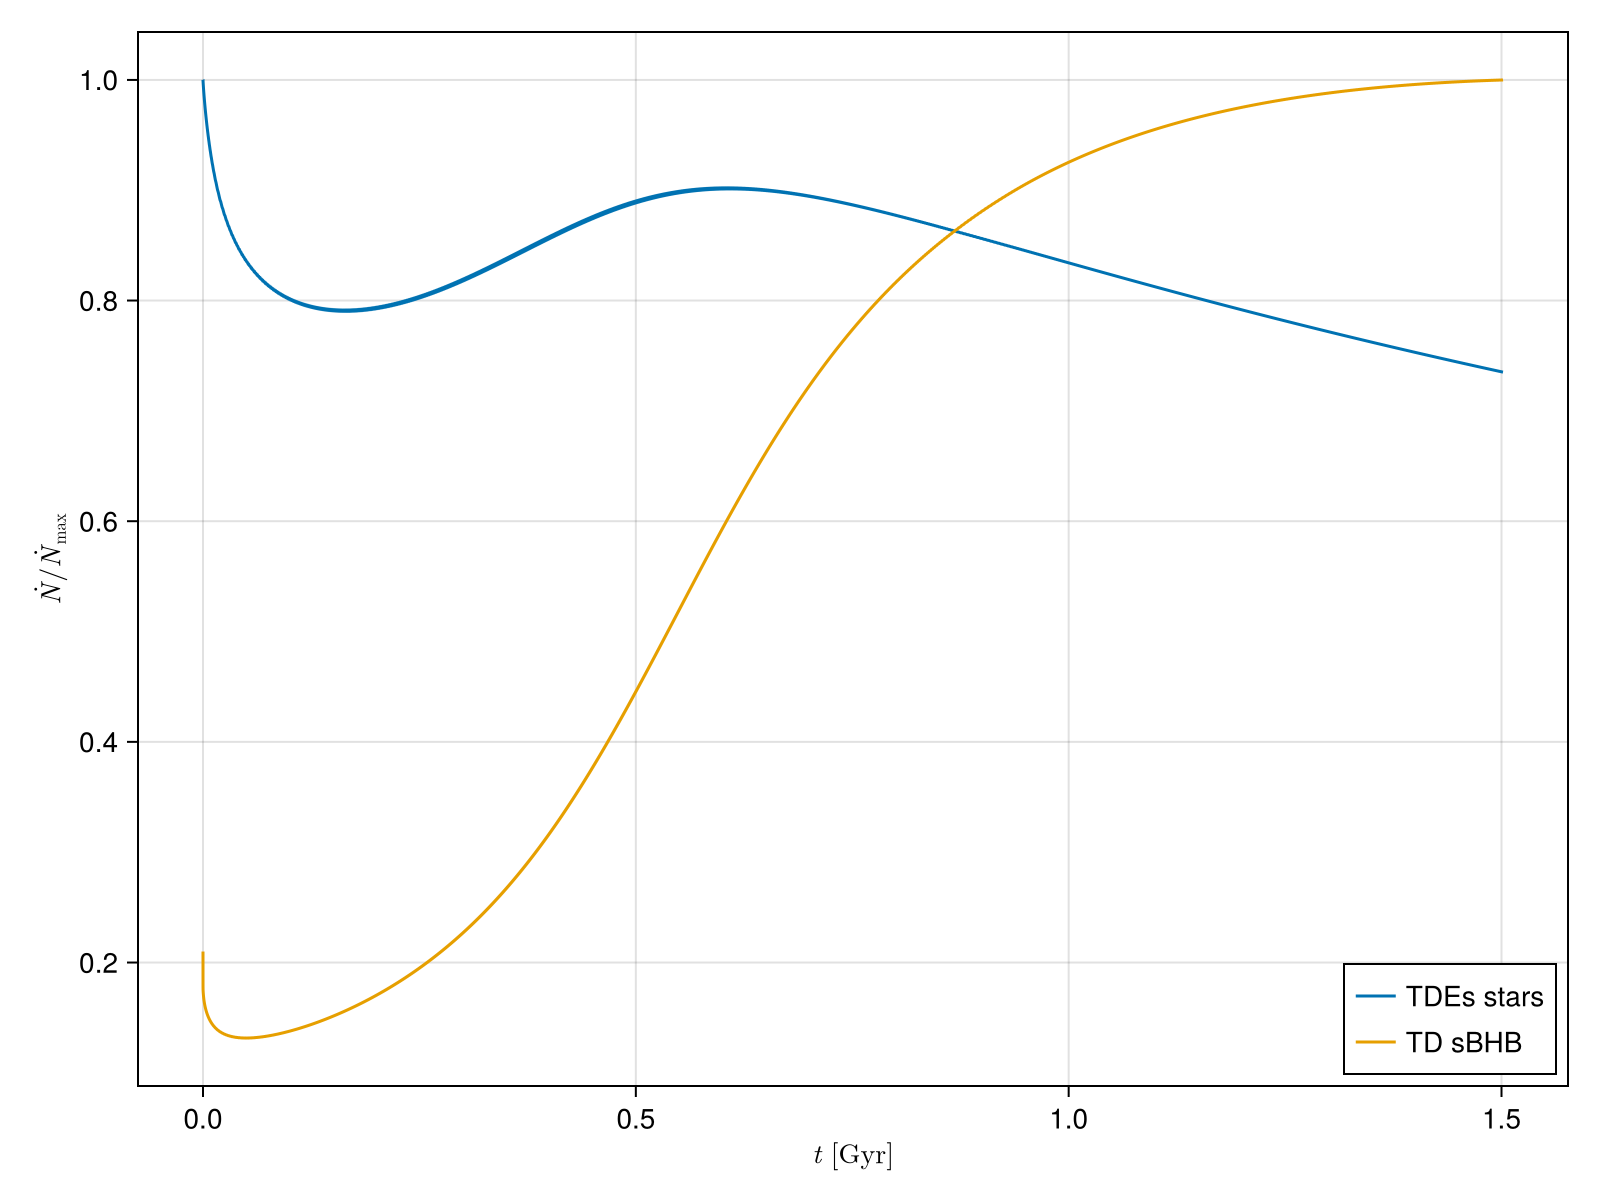

CairoMakie.Screen{IMAGE}


In [1]:
using JLD2, FileIO
using CairoMakie
using Printf
using Makie
using Dierckx

final_output = load("C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/summary_2_4.0e6_4.8e-7_100x100.jld2")
params = final_output["params"]
aux = final_output["aux"]

time = final_output["t"]/params["Gyr"]
TDE_rate = final_output["captures"][1] * params["Gyr"] * 1e-9
TDE_binary = final_output["captures"][2] * params["Gyr"] * 1e-9

TDE_norm=TDE_rate/maximum(TDE_rate)
TDE_binary_norm=TDE_binary/maximum(TDE_binary)

fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1], xlabel=L"$t$ [Gyr]", ylabel=L"\dot{N} / \dot{N}_{\max}")

lines!(ax, time, TDE_norm, label="TDEs stars")
lines!(ax, time, TDE_binary_norm, label="TD sBHB")

axislegend(ax, position=:rb)

display(fig)

In [2]:
function trapz(x, y)
    sum( 0.5 * (y[1:end-1] .+ y[2:end]) .* diff(x) )
end

@printf "TDE peak is: %.3e" maximum(TDE_binary)
 
@printf "TDE peak time is: %.3e" time[argmax(TDE_binary)] 

@printf "Total TDEs are: %.3e" trapz(time.*1e9, TDE_binary)

TDE peak is: 1.439e-06TDE peak time is: 1.502e+00Total TDEs are: 1.401e+03

Insert the time t1 in Gyr


stdin>  1


Insert the time t2 in Gyr:


stdin>  1.5


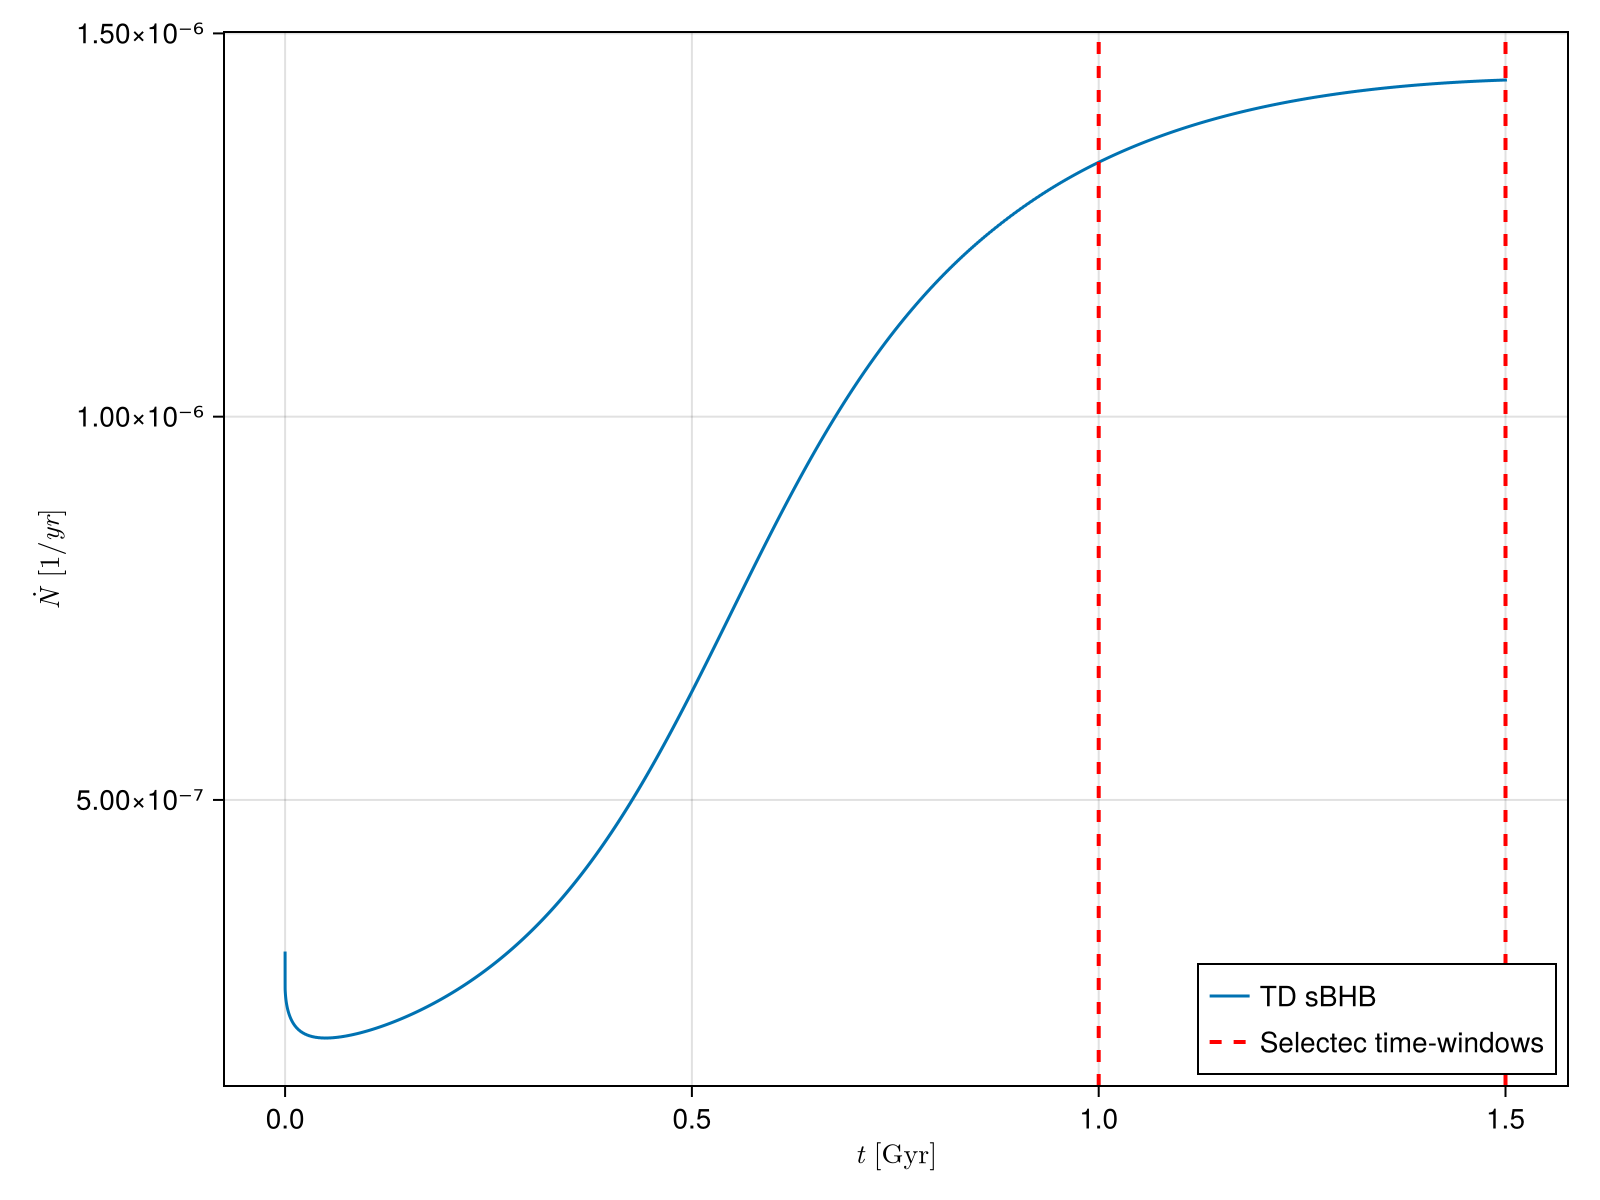

CairoMakie.Screen{PDF}


In [3]:
using SpecialFunctions
using LinearAlgebra

t=[]
indices_snapshot = 1:113

for i in indices_snapshot
    push!(t,time[i*40])
end

t_new=vcat(0,t)

println("Insert the time t1 in Gyr")
t1 = parse(Float64, readline())
println("Insert the time t2 in Gyr:")
t2 = parse(Float64, readline())
max_ind = findall(x -> t1 <= x <= t2, t)

fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1], xlabel=L"$t$ [Gyr]", ylabel=L"\dot{N}\ [1/yr] ")

lines!(ax, time, TDE_binary, label="TD sBHB")

vlines!(ax, [t1, t2], color=:red, linewidth=2, linestyle=:dash, label="Selectec time-windows")

axislegend(ax, position=:rb)

display(fig)

save("Selected timespan 4e6_0.1AU.pdf", fig)

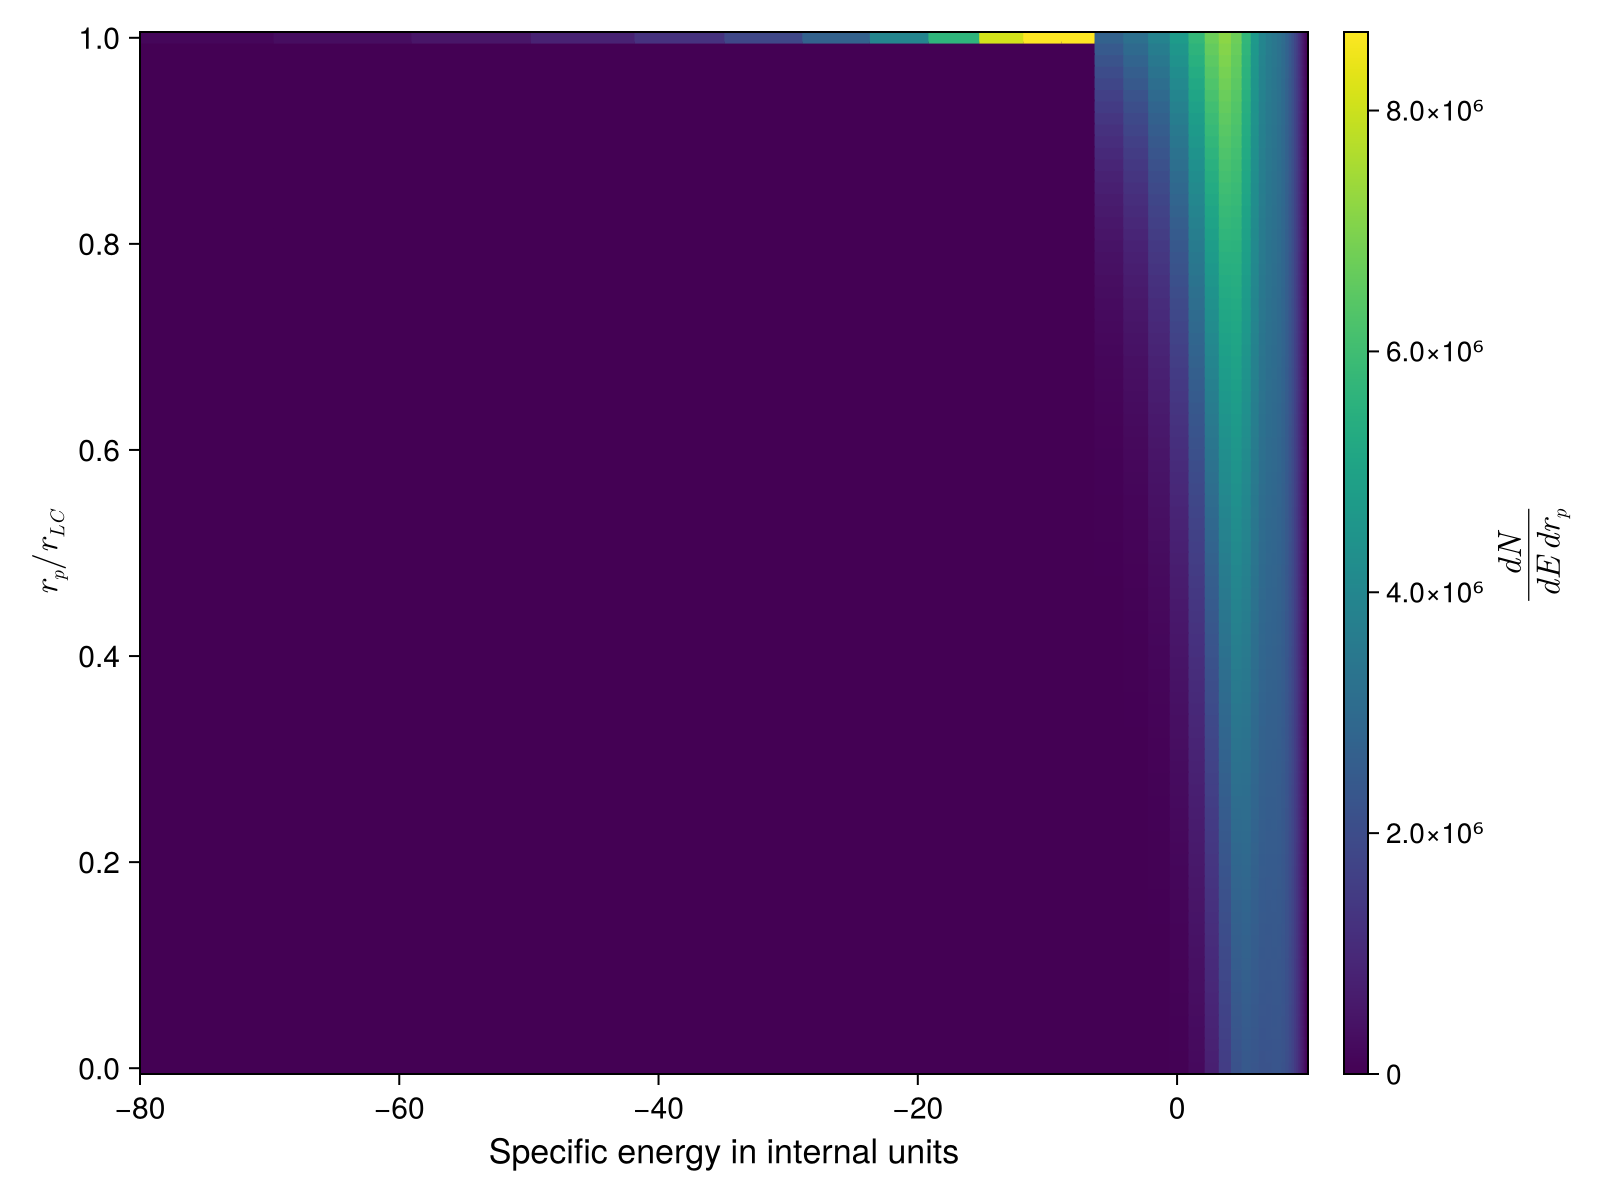

CairoMakie.Screen{IMAGE}


In [4]:
E = params["E0"] * (exp.(aux["s_val"]) .- 1.0)

function besseli_leo(x,y)
    return besseli(0, x)./besseli(1, y)
end

q_t=[]
f_t=[]
dN_dEdt=[]

for i in max_ind
    snapshot_file = "C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/snapshots_2_4.0e6_4.8e-7/snap_grid_100x100_$(@sprintf("%03d", i)).jld2"
    snap = load(snapshot_file)
    push!(dN_dEdt,snap["diff_rate"][2] * params["Gyr"])
    push!(q_t, snap["q"][2])
    push!(f_t, snap["f_e"][2])
end

dN_dEdt = Matrix(reduce(hcat, dN_dEdt)')
q_t = Matrix(reduce(hcat, q_t)')


N_E = length(E)
r_LC = final_output["params"]["rlc"][2]

N_rp = 90
r_p = range(0, r_LC; length=N_rp)
dx = step(r_p)

dNdrpdEdt = zeros(N_E, length(max_ind), N_rp)
dN_dEdt_2=dN_dEdt*0.0

for i in 1:N_E
    q = q_t[:,i]
    f = [ f_t[j][aux["Rlc_idx"][2][i], i] for j in 1:length(max_ind)]
    dNdrp_matrix = zeros(length(max_ind), length(r_p))
    for j in 1:length(max_ind)
        dN_dEdt_2[:,i]=4*pi^2*aux["l2c"][i]*q.*(q.^2+q.^4).^-0.25 .* f
        arg = @. 2 * sqrt.(r_p ./ (q[j] * r_LC))
        norm = 2 / sqrt(q[j])
        if q[j] < 0.01
            dN_drp = zeros(length(r_p))
            x0 = r_LC
            ix = findall(abs.(r_p .- x0) .< dx/2)
            dN_drp[ix] .= 1 / dx
        elseif q[j] > 10
            dN_drp = fill(1/r_LC, length(r_p))
        else
            dN_drp = (1/(r_LC*sqrt(q[j]))) .* @.besseli_leo(arg, norm)
        end
        dNdrp_matrix[j, :] .= dN_drp
    end
    dNdrpdEdt[i, :, :] = dN_dEdt_2[:,i] .* dNdrp_matrix
end

dNdrpdE = [trapz(t_new[max_ind], dNdrpdEdt[i, :, j]) for i in 1:length(E), j in 1:length(r_p)]

#redefine
yticks = 0:0.2:1.0
fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], xlabel="Specific energy in internal units", ylabel=L"r_{p}/r_{LC}", limits=(-80, 10.1, nothing, nothing), xlabelsize=17, ylabelsize=17, xticklabelsize=15, yticklabelsize=15, yticks=yticks)
hm = heatmap!(ax, -(E.-params["phis0"]), r_p/r_LC, dNdrpdE; colormap=:viridis, colorrange=(0, 0.5*maximum(dNdrpdE)))
Colorbar(fig[1,2], hm,  label = L"\frac{dN}{dE \, dr_p}", labelsize = 17)
display(fig)


In [5]:
#if you want to be curius about q

q_0=final_output["aux"]["q"]
fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], xlabel = "E", ylabel = L"q(E)", title = "q(E)")
lines!(ax, log10.(E), log10.(q_0[2]), color = :blue)
save("q(E)_2comp_1e6_0.1UA.pdf", fig)

CairoMakie.Screen{PDF}


In [6]:
using Distributions

dt = diff(t_new*1e9)
sub_TDE_binary=TDE_binary[1:40:end]
lambas=sub_TDE_binary[1:113].*dt
lamba2=trapz(t_new[max_ind],sub_TDE_binary[max_ind])

realizations= 1:1
TDE_final=[]
for j in realizations
    Total_TDE=[]
    for i in lambas
        y=rand(Poisson(i))
        push!(Total_TDE,y)
    end
    push!(TDE_final,Total_TDE[max_ind])
end

#TDE_final

In [7]:
using Random, Interpolations


accepted_energies_final=[]
for j in realizations
    accepted_energies = []
    for i in 1:length(max_ind)
        itp = interpolate((E,), dN_dEdt_2[i,:], Gridded(Linear()))
        
        p_max = maximum(dN_dEdt_2[i,:])
    
        N_TDE = TDE_final[j][i]
    
        E_min = minimum(E)
        E_max = maximum(E)
    
        Ei = Float64[]
        
        while length(Ei) < N_TDE
            E_trial = rand() * (E_max - E_min) + E_min
            y = rand() * p_max
            if y < itp(E_trial)
                push!(Ei, -(E_trial-params["phis0"]))
            end
        end
    
        push!(accepted_energies, Ei)
    end
    push!(accepted_energies_final, accepted_energies)
end

#accepted_energies_final


In [8]:
using SpecialFunctions
using LinearAlgebra

acepted_rp_total=[]
acepted_B_total=[]


for k in realizations
    accepted_rp = []
    accepted_B = []
    for i in max_ind
        snapshot_file = "C:/Users/kevin/OneDrive/Email attachments/Escritorio/Leopoldo/Maestria en astrofísica/Tesis/Code Luca/juliafokkerplanck/snapshots_2_1.0e6_4.8e-7/snap_grid_50x100_$(@sprintf("%03d", i)).jld2"
        snap = load(snapshot_file)
        energies = accepted_energies_final[k][i-minimum(max_ind)+1]
        q_E = snap["q"][2]
        itp_qE = interpolate((E,), q_E, Gridded(Linear()))
        rp= Float64[]
        B= Float64[]
        for j in energies
            q=itp_qE[-(j)+params["phis0"]]
            arg = @. 2 * sqrt.(r_p ./ (q * r_LC))
            norm = 2 / sqrt(q)
            if q < 0.01
                push!(rp,r_LC)
                push!(B, 1)
            elseif q > 10
                push!(rp, rand() * r_LC)
                push!(B, r_LC / (rand() * r_LC))
            else
                dN_drp = (1/(r_LC*sqrt(q))) .* @.besseli_leo(arg, norm)
                while true  
                    itp_rp = interpolate((collect(r_p),), dN_drp, Gridded(Linear()))
                    rp_trial = rand() * r_LC
                    p_max = maximum(dN_drp)
                    y = rand() * p_max
                    p_max = maximum(dN_drp)
                    if y < itp_rp(rp_trial)
                        push!(rp, rp_trial)
                        push!(B, r_LC/rp_trial)
                        break
                    end
                end
            end
        end
        push!(accepted_rp,rp)
        push!(accepted_B,B)
    end
    push!(acepted_rp_total, accepted_rp)
    push!(acepted_B_total, accepted_B)
end

#acepted_B_total

In [9]:
N_events=sum(TDE_final[1])
Specific_energies=vcat(vcat(accepted_energies_final...)...)*(params["sigma"]*(params["v_u"])/1000)^2 
Beta=vcat(vcat(acepted_B_total...)...)

#@printf "N of events are: %d\n" N_events

#println("The specific energies in (km/s)^2:")
#for e in Specific_energies
    #@printf "  %.3e\n" e
#end

#println("The penetration factors are:")
#for b in Beta
    #@printf "  %.3e\n" b
#end

764-element Vector{Float64}:
  1.1944148331979039
  1.8413043772709163
  3.0871177068187463
  1.0303010348604427
  5.366875000429826
 61.69668521795284
  1.0220439054686772
  1.0766139962789205
  1.1753359701999044
  1.9839143856365145
  1.0019953021680221
  1.351478947984442
  1.0
  ⋮
  1.1218913512435496
  2.0346889292379715
  4.105431531626391
  1.797891570776985
 17.388257084952684
  1.0656760594422732
  1.808407127354459
  4.038675796447112
  1.340709659421213
  1.2318028303263069
  1.9129013572174982
  1.300399792173271

N of events are: 251
The specific energies in (km/s)^2:
  1.283e+04
  -3.380e+04
  1.068e+04
  1.759e+04
  3.940e+03
  8.031e+03
  2.707e+04
  6.923e+03
  1.577e+04
  3.498e+03
  -7.881e+03
  3.269e+04
  -1.021e+04
  6.751e+03
  -1.613e+03
  2.876e+04
  -1.552e+03
  -1.557e+04
  2.811e+04
  -3.137e+04
  1.755e+04
  2.577e+04
  2.513e+04
  3.381e+04
  1.989e+04
  2.193e+04
  -1.010e+03
  1.809e+04
  3.500e+04
  -6.699e+03
  -8.138e+03
  3.029e+04
  8.030e+03
  -1.182e+05
  2.462e+04
  2.277e+04
  1.397e+04
  3.341e+04
  1.631e+04
  8.052e+03
  1.755e+04
  2.839e+04
  3.645e+04
  -1.088e+04
  3.731e+04
  1.668e+04
  3.046e+04
  7.131e+03
  -1.530e+04
  9.099e+03
  6.044e+03
  3.083e+04
  2.081e+04
  9.883e+03
  9.170e+03
  3.734e+04
  3.404e+04
  2.109e+03
  1.055e+04
  -1.566e+04
  1.146e+04
  -2.241e+04
  3.194e+03
  -2.688e+04
  9.208e+03
  9.683e+03
  -5.696e+02
  7.490e+03
  3.873e+03
  2.626e+03
  1.629e+04
  7.999e+03
  1.451e+04
  7.963e+03
  1.742e+04
  2.040e+04
  -1.156e+04
  

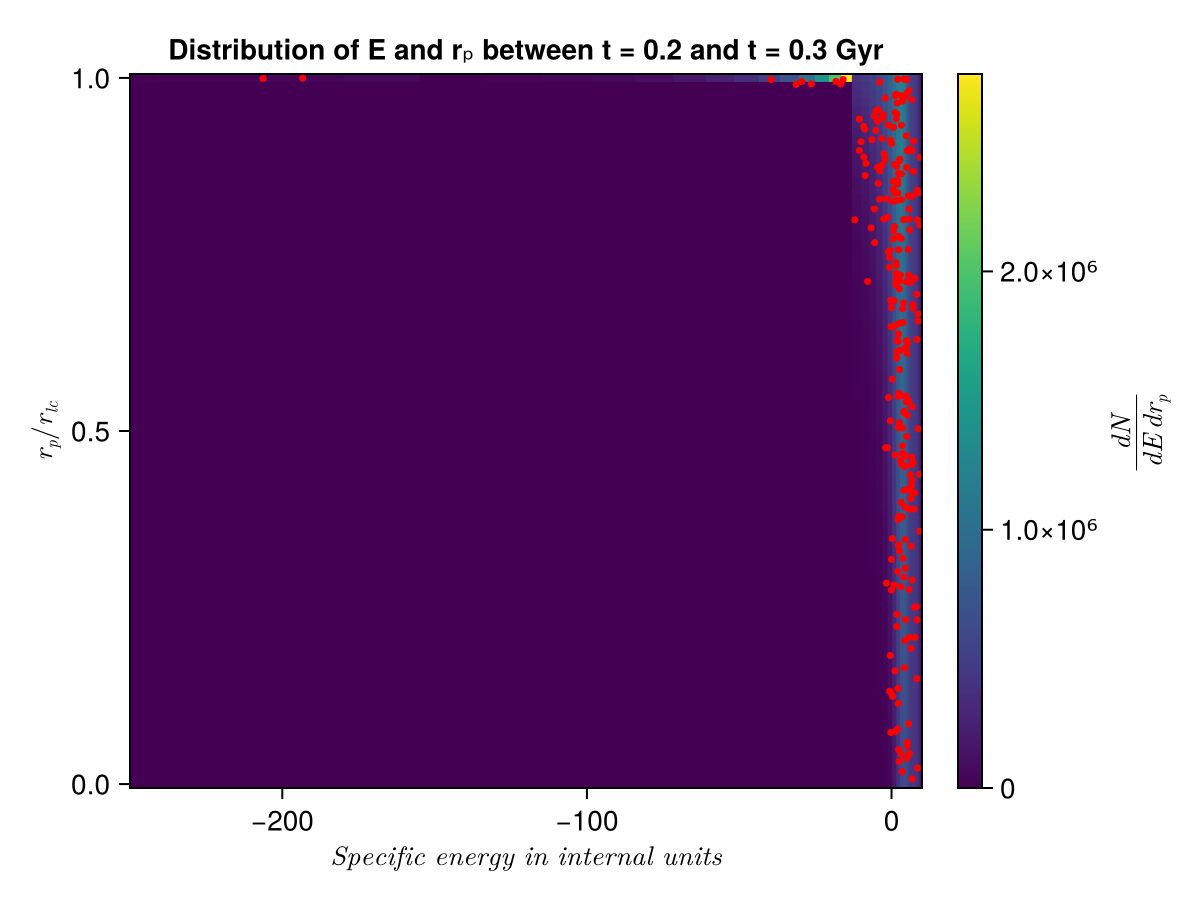

In [176]:
function sample_interpolated_heatmap(Z, x, y, N)
    
    itp = interpolate((x, y), Z, Gridded(Linear()))
    
    function find_first_allzero_col_from_end(Z)
        ncols = size(Z, 2)
        for col_idx in ncols:-1:1
            if all(Z[:, col_idx] .== 0)
                return col_idx
            end
        end
        return 2 
    end

    idx = find_first_allzero_col_from_end(Z)
    
    xmin, xmax = minimum(x), maximum(x)
    ymin, ymax = y[idx-1], maximum(y)
    samples = []

    while length(samples) < N
        x₀ = rand() * (xmax - xmin) + xmin
        y₀ = rand() * (ymax - ymin) + ymin
        z = itp[x₀, y₀]
        if rand() < z / maximum(Z)
            push!(samples, (x₀, y₀))
        end
    end

    return samples
end

vals1=[]
for i in 1:length(TDE_final[1])
    Evals2= sample_interpolated_heatmap(dNdrpdEdt[:,i,:], E, collect(r_p/r_LC), TDE_final[1][i])
    push!(vals1, Evals2 )
end

vals=vcat(vals1...)

Evals = [-(x[1]-params["phis0"]) for x in vals]
rpvals = [x[2] for x in vals]

Specific_energies_2=Evals*(params["sigma"]*(params["v_u"])/1000)^2
Beta_2=1 ./ rpvals

@printf "N of events are: %d\n" N_events

println("The specific energies in (km/s)^2:")
for e in Specific_energies_2
    @printf "  %.3e\n" e
end

println("The penetration factors are:")
for b in Beta_2
    @printf "  %.3e\n" b
end

fig = Figure()
ax = Axis(fig[1,1], xlabel=L"Specific\ energy\ in\ internal\ units", ylabel=L"r_{p}/r_{lc}", limits=(-250,10,nothing,nothing), title="Distribution of E and rₚ between t = $t1 and t = $t2 Gyr")
hm = heatmap!(ax, -(E.-params["phis0"]), r_p/r_LC, dNdrpdE; colormap=:viridis, colorrange=(0, maximum(dNdrpdE)))
Colorbar(fig[1,2], hm,  label = L"\frac{dN}{dE \, dr_p}")
CairoMakie.scatter!(ax, Evals, rpvals, markersize=5, color=:red)

display(fig)

save("E and rp dist with sampled points 1e4_0.1AU.pdf", fig)

filename = "1e4_2comp_0.1AU_data_summary.txt"

open(filename, "w") do io
    @printf(io, "Number of events between t = %.4f and %.4f Gyr: %d\n", t1, t2, N_events)
    @printf(io, "Mass of the MBH: %.2e solar masses\n\n", params["M"])
    
    @printf(io, "%-25s %-25s\n", "Specific energy [(km/s)^2]", "Penetration factor (Beta)")
    @printf(io, "%s\n", "-"^55)
    
    for (e, b) in zip(Specific_energies, Beta)
        @printf(io, "%-25.5e %-25.5e\n", e, b)
    end
    
    @printf(io, "\n\n")  
    @printf(io, "%-25s %-25s\n", "Specific energy [(km/s)^2]", "Penetration factor (Beta) using 2nd method")
    @printf(io, "%s\n", "-"^55)
    
    for (e, b) in zip(Specific_energies_2, Beta_2)
        @printf(io, "%-25.5e %-25.5e\n", e, b)
    end
end


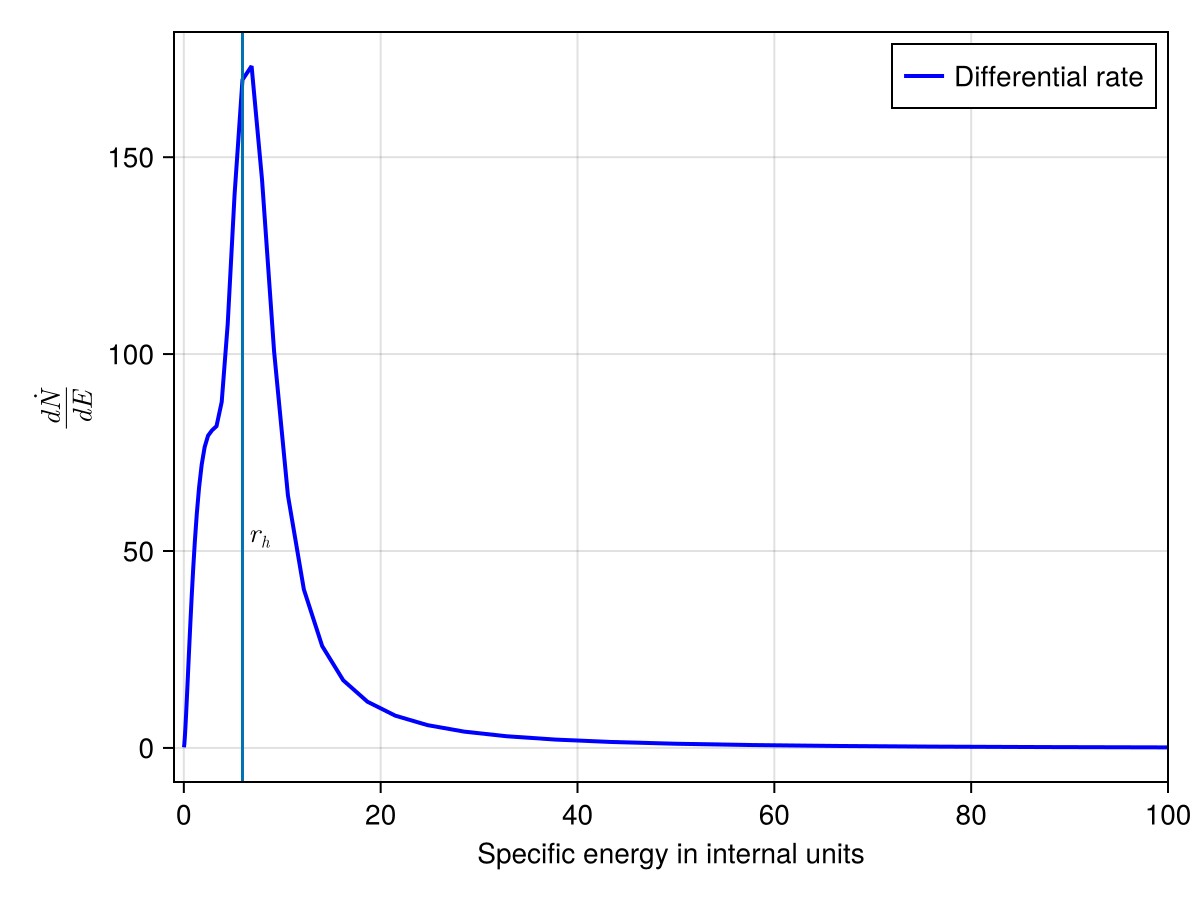

CairoMakie.Screen{PDF}


In [245]:
for i in 1:length(max_ind)
        itp = interpolate((E,), dN_dEdt_2[i,:], Gridded(Linear()))

        fig = Figure()
        ax = Axis(fig[1, 1]; xlabel="Specific energy in internal units", limits=(-1, 100,nothing,nothing), ylabel=L"\frac{d\dot{N}}{dE}", xticks=0:20:100)
        lines!(ax, E, dN_dEdt_2[i,:]; color=:blue, linewidth=2, label="Differential rate")
        p_max = maximum(dN_dEdt_2[i,:])
    
        N_TDE = 100
    
        E_min = minimum(E)
        E_max = maximum(E)
    
        Ei = Float64[]
        yi = Float64[]
        
        while length(Ei) < N_TDE
            E_trial = rand() * (E_max - E_min) + E_min
            y = rand() * p_max
            if y < itp(E_trial)
                push!(Ei, E_trial)
                push!(yi, y)
            end
        end
        #CairoMakie.scatter!(ax, Ei, yi; color=:red, markersize=7, label="Samples")
        vlines!(ax, E[findfirst( aux["rc"] .< params["rh"] )])
        text!(L"r_h", position = (1.1*(E[findfirst( aux["rc"] .< params["rh"] )]), 50))
        axislegend(ax)
end

display(fig)

save("last_figure.pdf", fig)

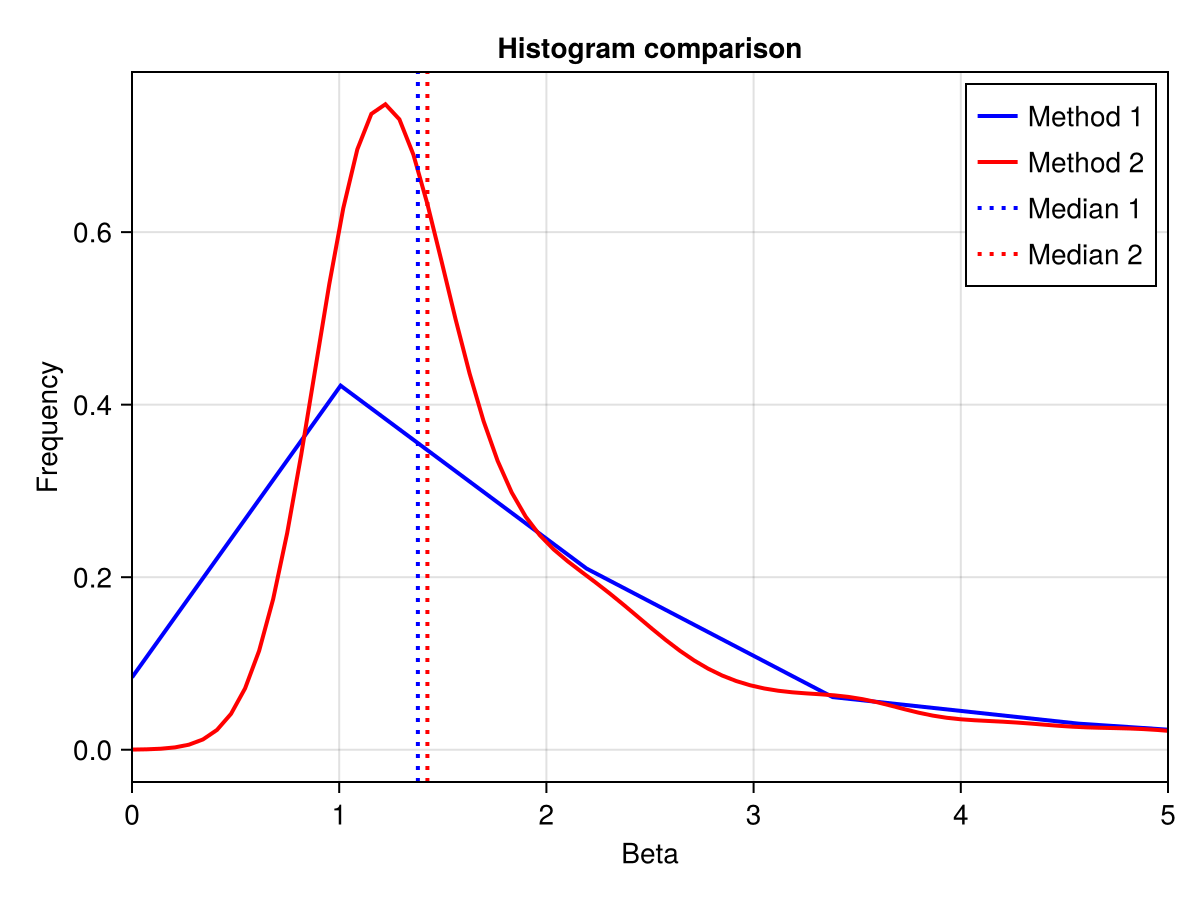

CairoMakie.Screen{IMAGE}


In [178]:
# check stuff

kde_result = kde(Beta)  
kde_result_2 = kde(Beta_2)  

x_vals = kde_result.x
pdf_vals = kde_result.density

x_vals_2 = kde_result_2.x
pdf_vals_2 = kde_result_2.density

med1 = median(Beta)
med2 = median(Beta_2)

fig = Figure()
ax = Axis(fig[1, 1]; xlabel="Beta", ylabel="Frequency", title="Histogram comparison", limits=(0, 5,nothing,nothing))

# Histogram
lines!(ax, x_vals, pdf_vals; color=:blue, linewidth=2, label="Method 1")
lines!(ax, x_vals_2, pdf_vals_2; color=:red, linewidth=2, label="Method 2")

vlines!(ax, [med1]; color=:blue, linestyle=:dot, linewidth=2, label="Median 1")
vlines!(ax, [med2]; color=:red, linestyle=:dot, linewidth=2, label="Median 2")

axislegend(ax)
display(fig)

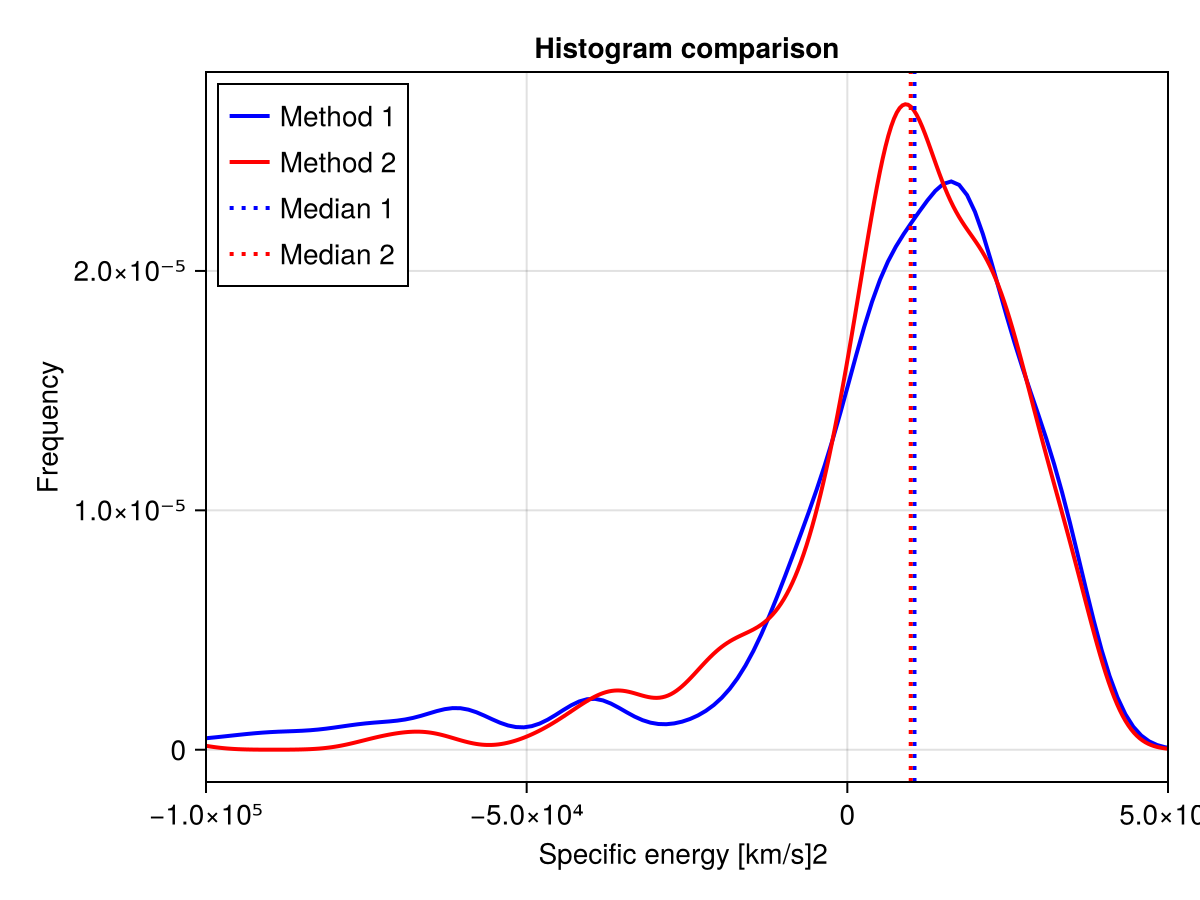

CairoMakie.Screen{IMAGE}


In [179]:
# check stuff
using KernelDensity, StatsBase, Random

#Specific_energies_1 = Specific_energies[Specific_energies .> -1e5]
kde_result = kde(Specific_energies)  
kde_result_2 = kde(Specific_energies_2)  

x_vals = kde_result.x
pdf_vals = kde_result.density

x_vals_2 = kde_result_2.x
pdf_vals_2 = kde_result_2.density

μ1 = mean(Specific_energies)
μ2 = mean(Specific_energies_2)

med1 = median(Specific_energies)
med2 = median(Specific_energies_2)

fig = Figure()
ax = Axis(fig[1, 1]; xlabel="Specific energy [km/s]2 ", ylabel="Frequency", title="Histogram comparison", limits=(-1e5, 5e4,nothing,nothing))

# Histogram
lines!(ax, x_vals, pdf_vals; color=:blue, linewidth=2, label="Method 1")
lines!(ax, x_vals_2, pdf_vals_2; color=:red, linewidth=2, label="Method 2")

vlines!(ax, [med1]; color=:blue, linestyle=:dot, linewidth=2, label="Median 1")
vlines!(ax, [med2]; color=:red, linestyle=:dot, linewidth=2, label="Median 2")

axislegend(ax, position = :lt)
display(fig)

In [10]:

fig = Figure()
ax = Axis(fig[1, 1],
    title = "Specific Energy distribution",
    xlabel = L"\text{Specific energy in } \mathrm{km}^2/\mathrm{s}^2",
    ylabel = L"N",
    limits = ((-5e5, 1e5), nothing),
    xticklabelsize = 15,
    yticklabelsize = 15,
    xlabelsize = 18,
    ylabelsize = 18,
    titlegap = 10,
    titlesize = 16,       
    backgroundcolor = :transparent,
    xticks = range(-5e5, stop=1e5, length=6)
)


# Histograma
hist!(ax, Specific_energies, bins=1000, color = :dodgerblue)
vlines!(ax, -(E[findfirst( aux["rc"] .< params["rh"] )]-params["phis0"])*(params["sigma"]*(params["v_u"])/1000)^2)
text!(L"r_h", position = (1.1*(-(E[findfirst( aux["rc"] .< params["rh"] )]-params["phis0"])*(params["sigma"]*(params["v_u"])/1000)^2), 15))

fig
println("La mediana es: ", median(Specific_energies))

save("a_4e6.pdf", fig)

La mediana es: 33645.99101932008


CairoMakie.Screen{PDF}


In [11]:
fig = Figure()
ax = Axis(fig[1, 1],
    title = "Beta distibution",
    xlabel = L"\beta",
    ylabel = L"N",
    limits = ((1, 20), nothing),
    xticklabelsize = 15,
    yticklabelsize = 15,
    xlabelsize = 18,
    ylabelsize = 18,
    titlegap = 10,
    titlesize = 16,       
    backgroundcolor = :transparent,
    xticks = range(1, 20, length=20)
)


# Histograma
hist!(ax, Beta, bins=1000, color = :dodgerblue)

fig

save("b_4e6.pdf", fig)

CairoMakie.Screen{PDF}


In [107]:
#trying to get the line t_gw = t_rlx

t_scatter_R = (aux["R_val"].^2 ./ (aux["DRR"] .* params["Gyr"])) .* aux["C"]
t_scatter_R[isnan.(t_scatter_R)] .= 0 
t_scatter_R

100×100 Matrix{Float64}:
   411.674        215.979       167.504      …    0.0       0.0       0.0
  2002.5          639.378       427.429           0.0       0.0       0.0
  5135.56        1237.12        729.509           0.0       0.0       0.0
 10365.8         2019.36       1098.11            0.0       0.0       0.0
 18043.4         3036.76       1545.14            0.0       0.0       0.0
 28690.9         4305.58       2052.17       …    0.0       0.0       0.0
 42456.3         5809.55       2643.5             0.0       0.0       0.0
 59813.9         7663.98       3340.14            0.0       0.0       0.0
 82448.0         9818.42       4103.35            0.0       0.0       0.0
     1.07623e5  12331.8        4989.78            0.0       0.0       0.0
     1.40198e5  15200.2        5979.65       …    0.0       0.0       0.0
     1.74603e5  18605.8        7045.09            0.0       0.0       0.0
     2.16997e5  22169.6        8300.77            0.0       0.0       0.0
     ⋮       

In [94]:
using Interpolations

a_rev = reverse(aux["rc"])
t_scatter_R = t_scatter_R[:, end:-1:1]

t_scatter_R_2 = ifelse.(t_scatter_R .== 0, 1e-20, t_scatter_R)

itp = interpolate((log10.(aux["R_val"]),log10.(a_rev)), log10.(t_scatter_R_2), Gridded(Linear()))

itp_loglog2d(xq, yq) = itp(log10.(xq), log10.(yq))

a = 10 .^ range(-5.4, 0; length=1000) #pc
R = range(0.005, 0.995; length=1000)

t_relax= 10 .^ itp_loglog2d(R,a)

1000×1000 Matrix{Float64}:
   1.0e-20        1.0e-20        1.0e-20      …    0.0132071    0.0134305
   1.0e-20        1.0e-20        1.0e-20           0.0158311    0.0161005
   1.0e-20        1.0e-20        1.0e-20           0.0184561    0.0187719
   1.0e-20        1.0e-20        1.0e-20           0.0210819    0.0214442
   1.0e-20        1.0e-20        1.0e-20           0.0237084    0.0241175
   1.0e-20        1.0e-20        1.0e-20      …    0.0263356    0.0267917
   1.0e-20        1.0e-20        1.0e-20           0.0289634    0.0294666
   1.0e-20        1.0e-20        1.0e-20           0.0315917    0.0321422
   1.0e-20        1.0e-20        1.0e-20           0.0342205    0.0348184
   1.0e-20        1.0e-20        1.0e-20           0.0368497    0.0374951
   1.0e-20        1.0e-20        1.0e-20      …    0.0394794    0.0401725
   1.0e-20        1.0e-20        1.0e-20           0.0421974    0.0429392
   1.0e-20        1.0e-20        1.0e-20           0.0449303    0.0457212
   ⋮       

In [95]:
#ok tGW 
#c=3.066e5 #pc Gyr-1
#G=4.49e-12 #pc3 solar -1 Gyr-1
G = 6.67430e-11          # m^3 kg^-1 s^-2
c = 299792458.0          # m/s
Msun = 1.989e30          # kg
pc = 3.085677581e16      # m
seconds_in_Gyr = 3.1536e16  # s
M = 4.3e6 * Msun         
m = 10 * Msun            
R_col = reshape(R, :, 1)
a_row = reshape(a, 1, :)
a_new = a_row .* pc       

function tGW(a, R)
    return ((15/304) * (c^5 .* a.^4 )./ (G^3 * M * m * (M + m)) .* ((1 .- sqrt.(1 .- R)) .*  (R .^(5/2)))./(sqrt.(1 .- R)) .* (1+ (121/304).*(-R.+1)).^(-1))
end                                                                                               

tGW_matrix = (tGW.(a_new, R_col)) ./ seconds_in_Gyr

1000×1000 Matrix{Float64}:
 6.33808e-15  6.66162e-15  7.00166e-15  …  2.2841e7    2.40069e7   2.52324e7
 1.19469e-14  1.25567e-14  1.31977e-14     4.30539e7   4.52516e7   4.75615e7
 2.04354e-14  2.14785e-14  2.25749e-14     7.36444e7   7.74037e7   8.13548e7
 3.25519e-14  3.42135e-14  3.596e-14       1.1731e8    1.23298e8   1.29591e8
 4.91025e-14  5.1609e-14   5.42434e-14     1.76954e8   1.85987e8   1.95481e8
 7.09479e-14  7.45695e-14  7.8376e-14   …  2.5568e8    2.68731e8   2.82449e8
 9.90005e-14  1.04054e-13  1.09366e-13     3.56775e8   3.74987e8   3.94128e8
 1.34222e-13  1.41074e-13  1.48275e-13     4.83706e8   5.08398e8   5.34349e8
 1.77624e-13  1.86691e-13  1.9622e-13      6.40114e8   6.72789e8   7.07132e8
 2.3026e-13   2.42014e-13  2.54368e-13     8.29804e8   8.72162e8   9.16682e8
 2.93232e-13  3.08201e-13  3.23933e-13  …  1.05674e9   1.11068e9   1.16738e9
 3.67685e-13  3.86454e-13  4.06181e-13     1.32505e9   1.39269e9   1.46378e9
 4.54805e-13  4.7802e-13   5.02421e-13     1.6390

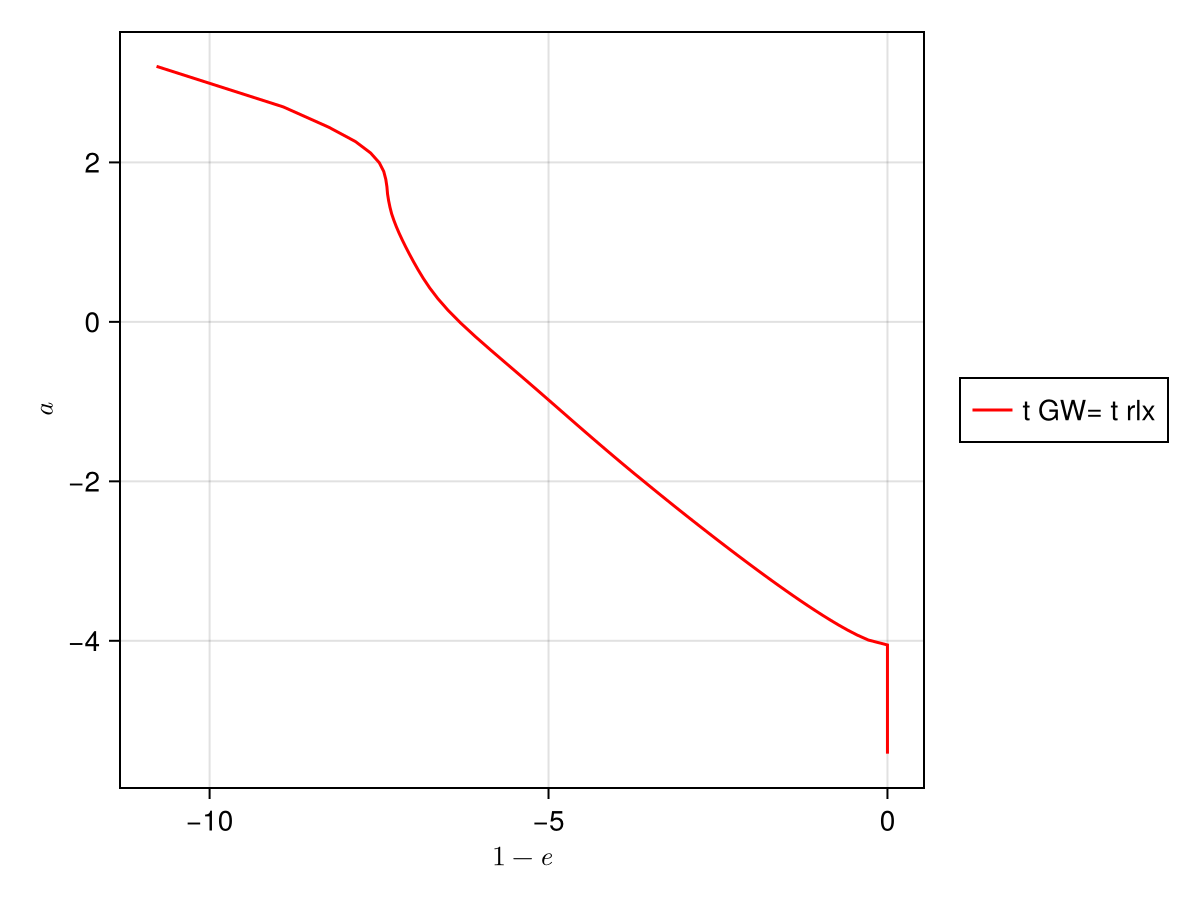

CairoMakie.Screen{IMAGE}


In [122]:
difference  = tGW_matrix .- t_relax
R_eq=[]
for a in eachindex(aux["rc"])
    validindex=aux["R_val"].>aux["Rlc"][2][a]
    if any(validindex)
        itp_rlx=linear_interpolation(log10.(aux["R_val"][validindex]), log10.(t_scatter_R[validindex,a]), extrapolation_bc=Line())
        trlx(R)=exp10(itp_rlx(log10(R)))
#trlx = trlc^LC * R/Rlc, can be writting
#tGW = tGW^LC * (R/RLC)^3.5 scalings for very eccentric orbits 
# (R/RLC) = (trlx^LC/tGW^LC)^(2/5)
# R_tgwtrlx = RLC * (trlx^LC/tGW^LC)^(2/5) #valuo of R when both are equal , inside the loop.
        trlx_lc=trlx(aux["Rlc"][2][a])
        tGW_lc=tGW(aux["rc"][a]*pc, aux["Rlc"][2][a])/seconds_in_Gyr
        push!(R_eq, min((aux["Rlc"][2][a]*(trlx_lc/tGW_lc)^(2/5)),1))
    else 
        push!(R_eq, 1)
    end
end

fig = Figure()
ax = Axis(fig[1, 1], xlabel=L"1-e", ylabel=L"a")
lines!(ax, log10.(-sqrt.(-R_eq.+1).+1), log10.(aux["rc"]), color=:red, label="t GW= t rlx")
Legend(fig[1, 2], ax)
display(fig)
#we get t_gw = t_rlx

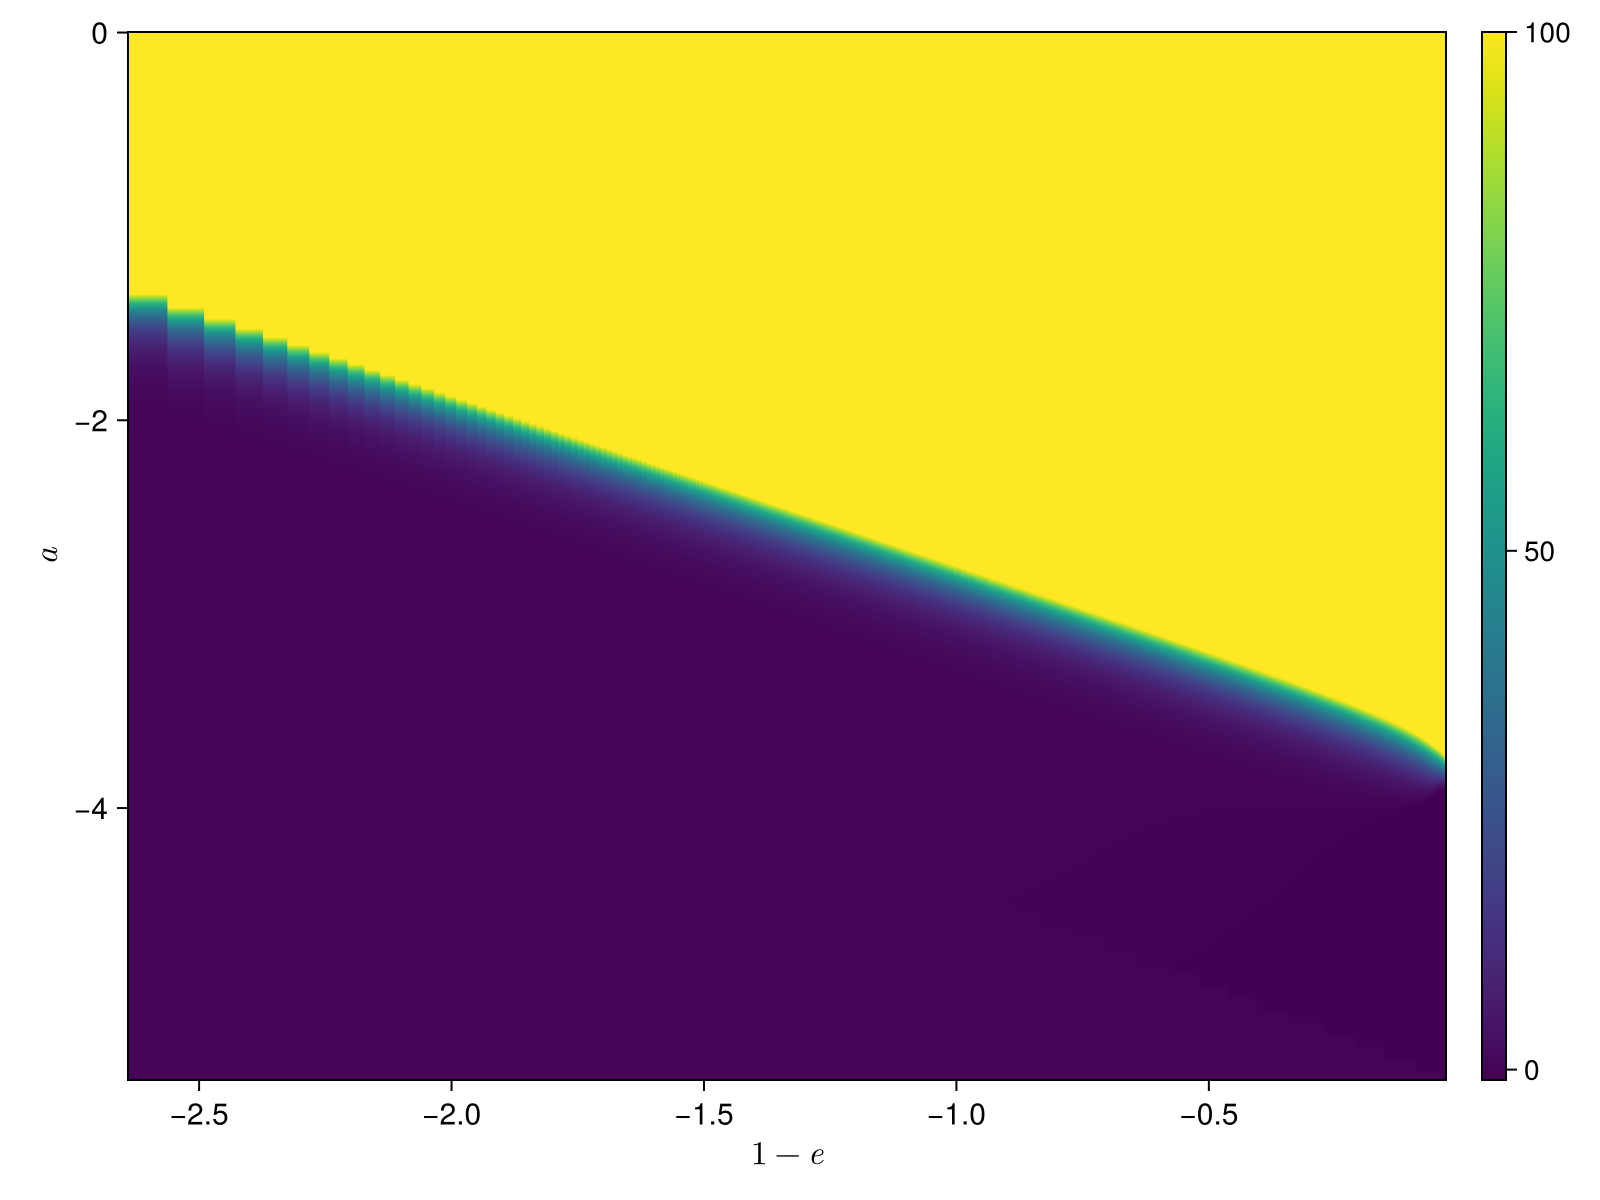

CairoMakie.Screen{IMAGE}


In [97]:
fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], xlabel=L"1-e", ylabel=L"a", xlabelsize=17, ylabelsize=17, xticklabelsize=15, yticklabelsize=15)
hm = heatmap!(ax, log10.(-sqrt.(-R.+1).+1), log10.(collect(a)), difference; colormap=:viridis, colorrange=(-1, 100))
Colorbar(fig[1,2], hm, labelsize = 17)
display(fig)

In [98]:
zero_indices = findall(difference .< 0)
R_zero = [R[i[1]] for i in zero_indices]
a_zero = [a[i[2]] for i in zero_indices];

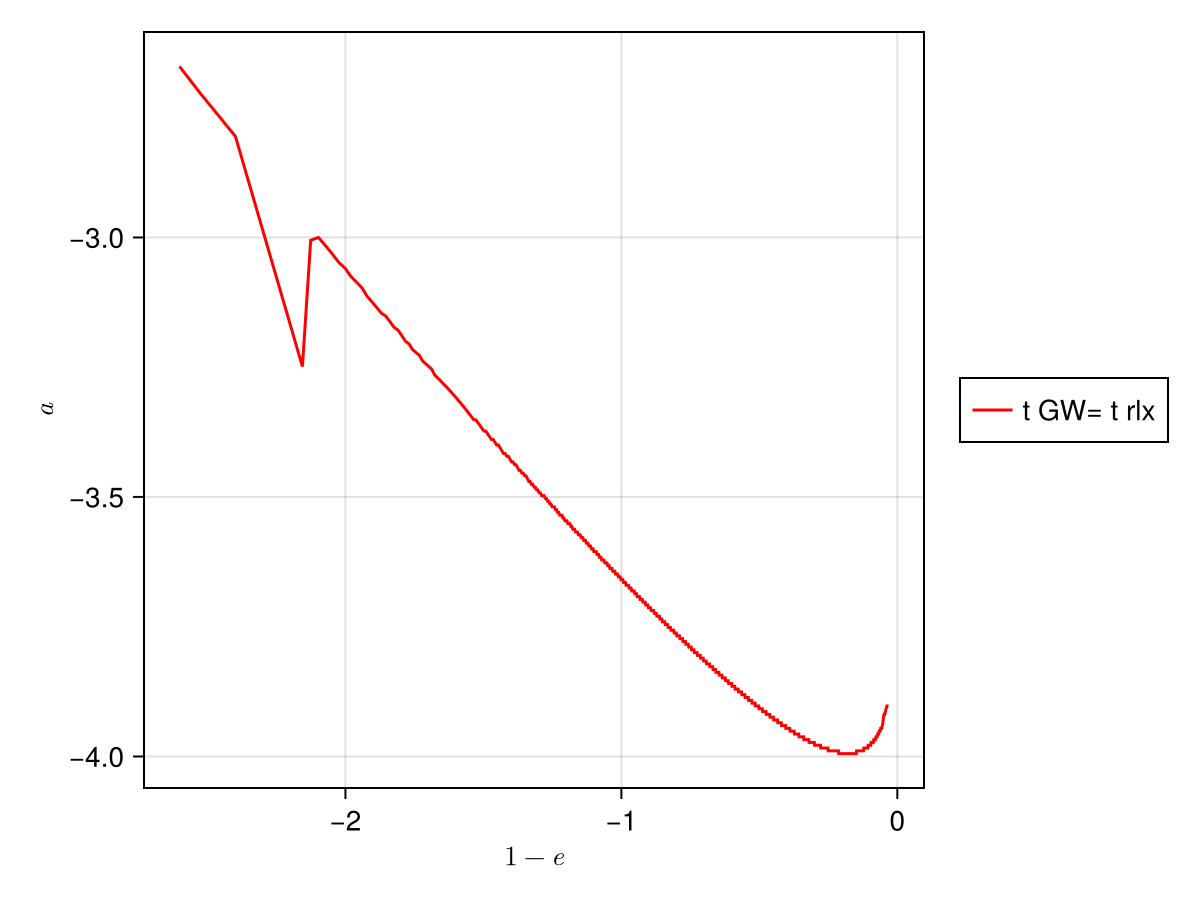

CairoMakie.Screen{IMAGE}


In [99]:
max_points = Dict{Float64, Float64}()

for (xi, yi) in zip(R_zero, a_zero)
    if haskey(max_points, xi)
        max_points[xi] = max(max_points[xi], yi)
    else
        max_points[xi] = yi
    end
end

x_unique = collect(keys(max_points))
y_max = [max_points[xi] for xi in x_unique]

sort_idx = sortperm(x_unique)
R_0 = x_unique[sort_idx]
a_0 = y_max[sort_idx]

fig = Figure()
ax = Axis(fig[1, 1], xlabel=L"1-e", ylabel=L"a")
lines!(ax, log10.(-sqrt.(-R_0.+1).+1), log10.(a_0), color=:red, label="t GW= t rlx")
Legend(fig[1, 2], ax)
display(fig)

In [100]:
using CSV, DataFrames, StatsBase, Distributions
using CategoricalArrays

df = CSV.read("fractions_data_E0.csv", DataFrame)

n_bins = 200
beta_vals = df.beta_0
D1_vals = df.D1
edges = range(minimum(beta_vals), stop=maximum(beta_vals), length=n_bins+1)
bin_centers = [0.5*(edges[i] + edges[i+1]) for i in 1:n_bins]

bin_cats = cut(beta_vals, edges; extend=true)
bin_indices = bin_cats.refs
D1_means = [mean(D1_vals[bin_indices .== i]) for i in 1:n_bins]

sim_bin_counts = zeros(Int, n_bins)
Beta_filtered = Beta[(Beta .>= 1) .& (Beta .<= maximum(beta_vals))]

for i in 1:n_bins
    a = edges[i]
    b = edges[i+1]
    sim_bin_counts[i] = count(x -> a <= x < b, Beta_filtered)
end

poisson_results = zeros(Int, n_bins)

for i in 1:n_bins
    n_sim = sim_bin_counts[i]
    eff = isnan(D1_means[i]) ? 0.0 : D1_means[i]
    λ = n_sim * eff
    poisson_results[i] = rand(Poisson(λ))
end

resultado = hcat(bin_centers, poisson_results)

#println("Bin center  |  remains sBH (Poisson)")
#for i in 1:n_bins
#    println(@sprintf("%10.4f      %10d", bin_centers[i], poisson_results[i]))
#end

200×2 Matrix{Float64}:
  1.035  71.0
  1.105  37.0
  1.175  23.0
  1.245  42.0
  1.315  17.0
  1.385  23.0
  1.455  18.0
  1.525  15.0
  1.595  14.0
  1.665  13.0
  1.735   9.0
  1.805   7.0
  1.875   8.0
  ⋮      
 14.195   0.0
 14.265   0.0
 14.335   0.0
 14.405   4.0
 14.475   0.0
 14.545   1.0
 14.615   0.0
 14.685   0.0
 14.755   1.0
 14.825   0.0
 14.895   0.0
 14.965   0.0

In [101]:
using KernelDensity

df_2 = CSV.read("M4e6_E0.csv", DataFrame)

sampled_a = Float64[]
sampled_e = Float64[]

for i in 1:n_bins
    beta_min = edges[i]
    beta_max = edges[i+1]
    n_events = poisson_results[i]

    bin_data = filter(row -> beta_min ≤ row.beta_0 < beta_max, df_2)

    if n_events > 0
        x = bin_data.a_cap
        y = bin_data.e_cap
        points = hcat(x, y)
        
        # KDE 2D
        kde_0 = kde(points)

        for j in 1:n_events
            accepted = false
            while !accepted
                a_try = rand(Uniform(minimum(x), maximum(x)))
                e_try = rand(Uniform(minimum(y), maximum(y)))
                p = pdf(kde_0, a_try, e_try)

                p_max = maximum(kde_0.density)
                if rand() < p / p_max
                    push!(sampled_a, a_try)
                    push!(sampled_e, e_try)
                    accepted = true
                end
            end
        end
    end
end

@show length(sampled_a)
@show length(sampled_e)

length(sampled_a) = 558
length(sampled_e) = 558


558

In [102]:
#the loss cone for the remains BH

x_vals = range(-4, 0, length=200)
const_val = log10((8 * G * M / c^2)*3.24e-17) 
y_vals = .-x_vals .+ const_val;

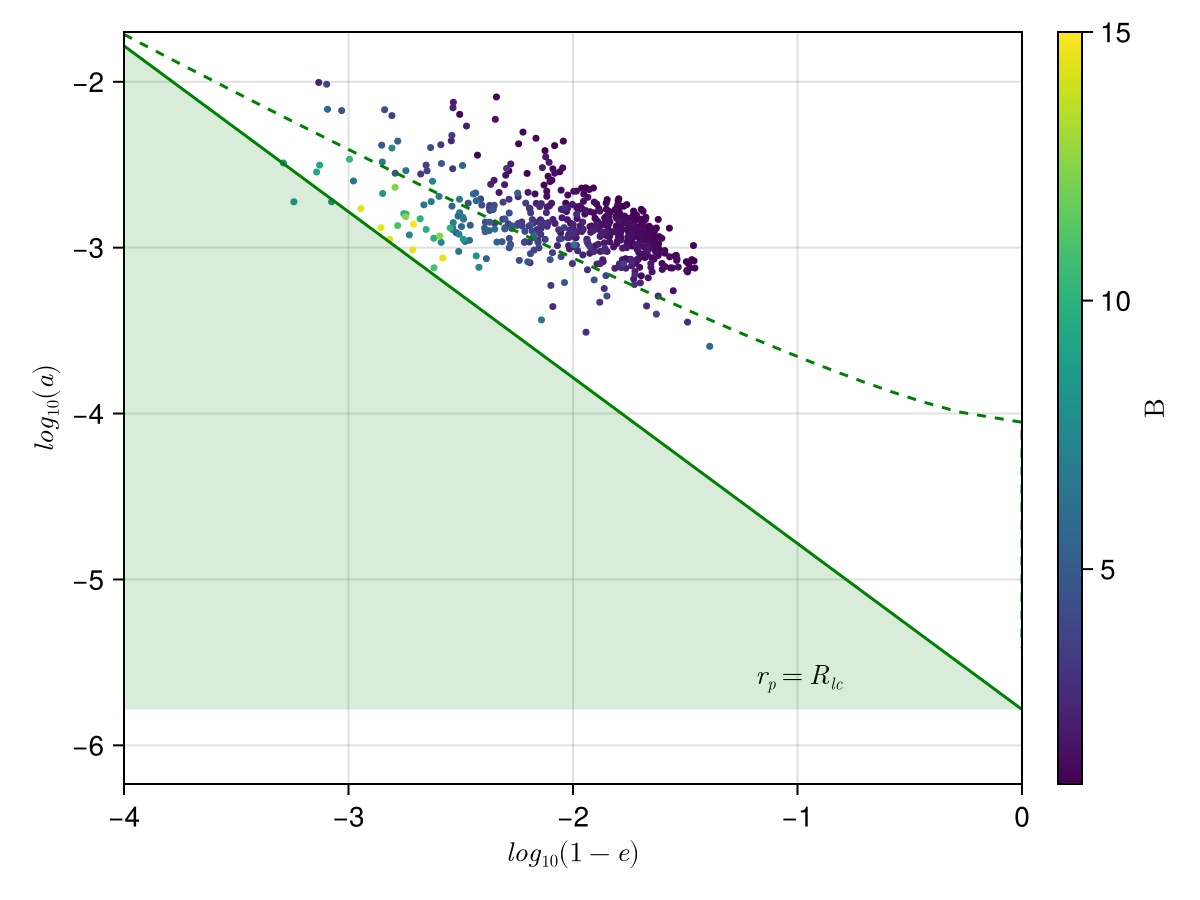

CairoMakie.Screen{IMAGE}


In [126]:
colors_labels = Float64[]
for (cant, val) in zip(poisson_results, bin_centers)
    append!(colors_labels, fill(val, cant))
end

fig = Figure()
ax = Axis(fig[1, 1], xlabel=L"log_{10}(1-e)", ylabel=L"log_{10}(a)")
sc=scatter!(ax, log10.(-sampled_e.+1), log10.(sampled_a), color = colors_labels, colormap = :viridis, colorrange = (1, 15),  markersize = 5)
lines!(ax, x_vals, y_vals, color=:green, label=L"r_{LC}")
text!(ax, [maximum(x_vals) - 0.8], [y_vals[end] + 0.1], text=L"r_p = R_{lc}", align=(:right, :bottom))
lines!(ax, log10.(-sqrt.(-R_eq.+1).+1), log10.(aux["rc"]), color=:green, label="t GW= t rlx",  linestyle=:dash)
#text!(ax, [maximum(log10.(-sqrt.(-R_0.+1).+1)) - 0.8], [log10.(a_0)[end] + 0.1], text=L"t_{\mathrm{GW}} = t_{\mathrm{rlx}}", align=(:right, :bottom))
poly!(ax,[x_vals; reverse(x_vals)],[fill(minimum(y_vals), length(x_vals)); reverse(y_vals)],color=(:green, 0.15), strokewidth=0)
Colorbar(fig[1, 2], sc, label = L"\Beta")
CairoMakie.xlims!(-4,0)
CairoMakie.ylims!(nothing,-1.7)
display(fig)

#evolving with rp = cts paralel to the LC , simulation of peter eq.
#do it with a bulk around -2

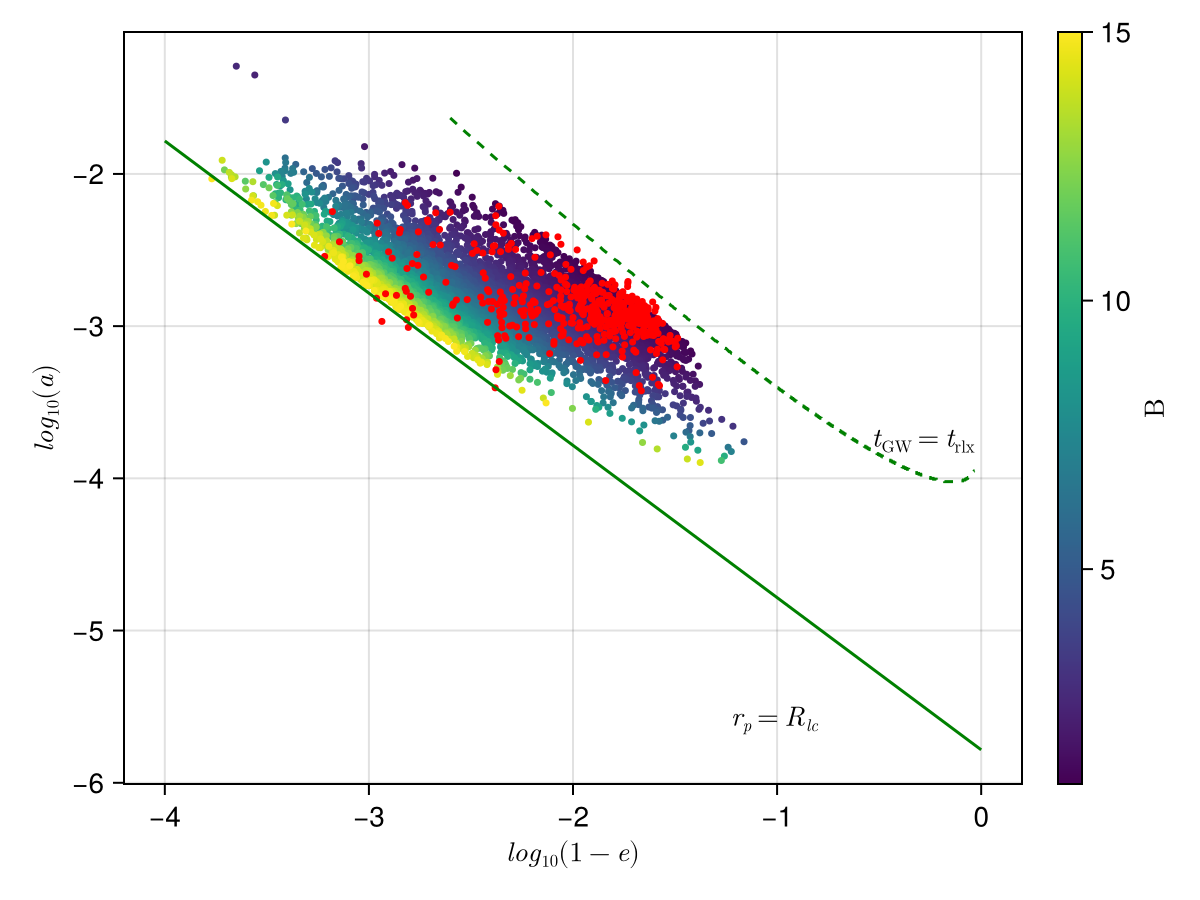

CairoMakie.Screen{IMAGE}


In [31]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel=L"log_{10}(1-e)", ylabel=L"log_{10}(a)")
sc=scatter!(ax, log10.(-df_2.e_cap.+1), log10.(df_2.a_cap), color = df_2.beta_0, colormap = :viridis, colorrange = (1, 15),  markersize = 5)
sc2=scatter!(ax, log10.(-sampled_e.+1), log10.(sampled_a), color = :red, markersize = 5)
lines!(ax, x_vals, y_vals, color=:green, label=L"r_{LC}")
text!(ax, [maximum(x_vals) - 0.8], [y_vals[end] + 0.1], text=L"r_p = R_{lc}", align=(:right, :bottom))
lines!(ax, log10.(-sqrt.(-R_0.+1).+1), log10.(a_0), color=:green, label="t GW= t rlx",  linestyle=:dash)
text!(ax, [maximum(log10.(-sqrt.(-R_0.+1).+1))], [log10.(a_0)[end] + 0.1], text=L"t_{\mathrm{GW}} = t_{\mathrm{rlx}}", align=(:right, :bottom))
Colorbar(fig[1, 2], sc, label = L"\Beta")
display(fig)

In [32]:
# con la otra

df_0 = CSV.read("fractions_data_E1.csv", DataFrame)


n_bins = 200
beta_vals = df_0.beta_0
D1_vals = df_0.D1
edges = range(minimum(beta_vals), stop=maximum(beta_vals), length=n_bins+1)
bin_centers = [0.5*(edges[i] + edges[i+1]) for i in 1:n_bins]

bin_cats = cut(beta_vals, edges; extend=true)
bin_indices = bin_cats.refs
D1_means = [mean(D1_vals[bin_indices .== i]) for i in 1:n_bins]

sim_bin_counts = zeros(Int, n_bins)
Beta_filtered = Beta[(Beta .>= 1) .& (Beta .<= maximum(beta_vals))]

for i in 1:n_bins
    a = edges[i]
    b = edges[i+1]
    sim_bin_counts[i] = count(x -> a <= x < b, Beta_filtered)
end

poisson_results = zeros(Int, n_bins)

for i in 1:n_bins
    n_sim = sim_bin_counts[i]
    eff = isnan(D1_means[i]) ? 0.0 : D1_means[i]
    λ = n_sim * eff
    poisson_results[i] = rand(Poisson(λ))
end

resultado = hcat(bin_centers, poisson_results)

#println("Bin center  |  remains sBH (Poisson)")
#for i in 1:n_bins
#    println(@sprintf("%10.4f      %10d", bin_centers[i], poisson_results[i]))
#end

200×2 Matrix{Float64}:
  1.035  55.0
  1.105  38.0
  1.175  40.0
  1.245  32.0
  1.315  16.0
  1.385  29.0
  1.455  14.0
  1.525   7.0
  1.595   8.0
  1.665   7.0
  1.735  11.0
  1.805   9.0
  1.875   7.0
  ⋮      
 14.195   0.0
 14.265   0.0
 14.335   0.0
 14.405   2.0
 14.475   0.0
 14.545   2.0
 14.615   0.0
 14.685   0.0
 14.755   0.0
 14.825   0.0
 14.895   0.0
 14.965   0.0

In [33]:
df_02 = CSV.read("M4e6_E1.csv", DataFrame)

sampled_a = Float64[]
sampled_e = Float64[]

for i in 1:n_bins
    beta_min = edges[i]
    beta_max = edges[i+1]
    n_events = poisson_results[i]

    bin_data = filter(row -> beta_min ≤ row.beta_0 < beta_max, df_02)

    if n_events > 0 
        x = bin_data.a_cap
        y = bin_data.e_cap
        points = hcat(x, y)
        
        kde_0 = kde(points)

        for j in 1:n_events
            accepted = false
            while !accepted
                a_try = rand(Uniform(minimum(x), maximum(x)))
                e_try = rand(Uniform(minimum(y), maximum(y)))
                p = pdf(kde_0, a_try, e_try)

                p_max = maximum(kde_0.density)
                if rand() < p / p_max
                    push!(sampled_a, a_try)
                    push!(sampled_e, e_try)
                    accepted = true
                end
            end
        end
    end
end

@show length(sampled_a)
@show length(sampled_e)

length(sampled_a) = 501
length(sampled_e) = 501


501

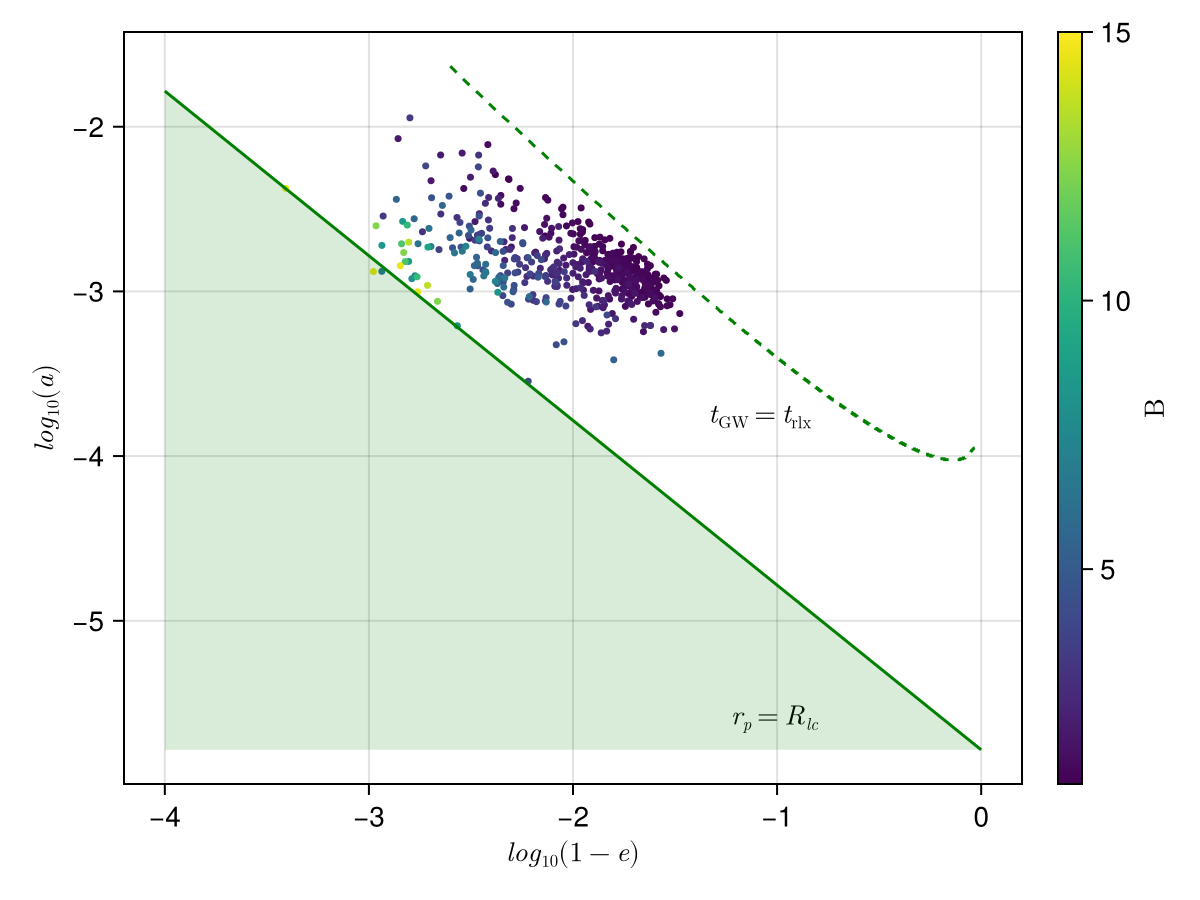

CairoMakie.Screen{IMAGE}


In [34]:
colors_labels = Float64[]
for (cant, val) in zip(poisson_results, bin_centers)
    append!(colors_labels, fill(val, cant))
end

fig = Figure()
ax = Axis(fig[1, 1], xlabel=L"log_{10}(1-e)", ylabel=L"log_{10}(a)")
sc=scatter!(ax, log10.(-sampled_e.+1), log10.(sampled_a), color = colors_labels, colormap = :viridis, colorrange = (1, 15),  markersize = 5)
lines!(ax, x_vals, y_vals, color=:green, label=L"r_{LC}")
text!(ax, [maximum(x_vals) - 0.8], [y_vals[end] + 0.1], text=L"r_p = R_{lc}", align=(:right, :bottom))
lines!(ax, log10.(-sqrt.(-R_0.+1).+1), log10.(a_0), color=:green, label="t GW= t rlx",  linestyle=:dash)
text!(ax, [maximum(log10.(-sqrt.(-R_0.+1).+1)) - 0.8], [log10.(a_0)[end] + 0.1], text=L"t_{\mathrm{GW}} = t_{\mathrm{rlx}}", align=(:right, :bottom))
poly!(ax,[x_vals; reverse(x_vals)],[fill(minimum(y_vals), length(x_vals)); reverse(y_vals)],color=(:green, 0.15), strokewidth=0)
Colorbar(fig[1, 2], sc, label = L"\Beta")
display(fig)

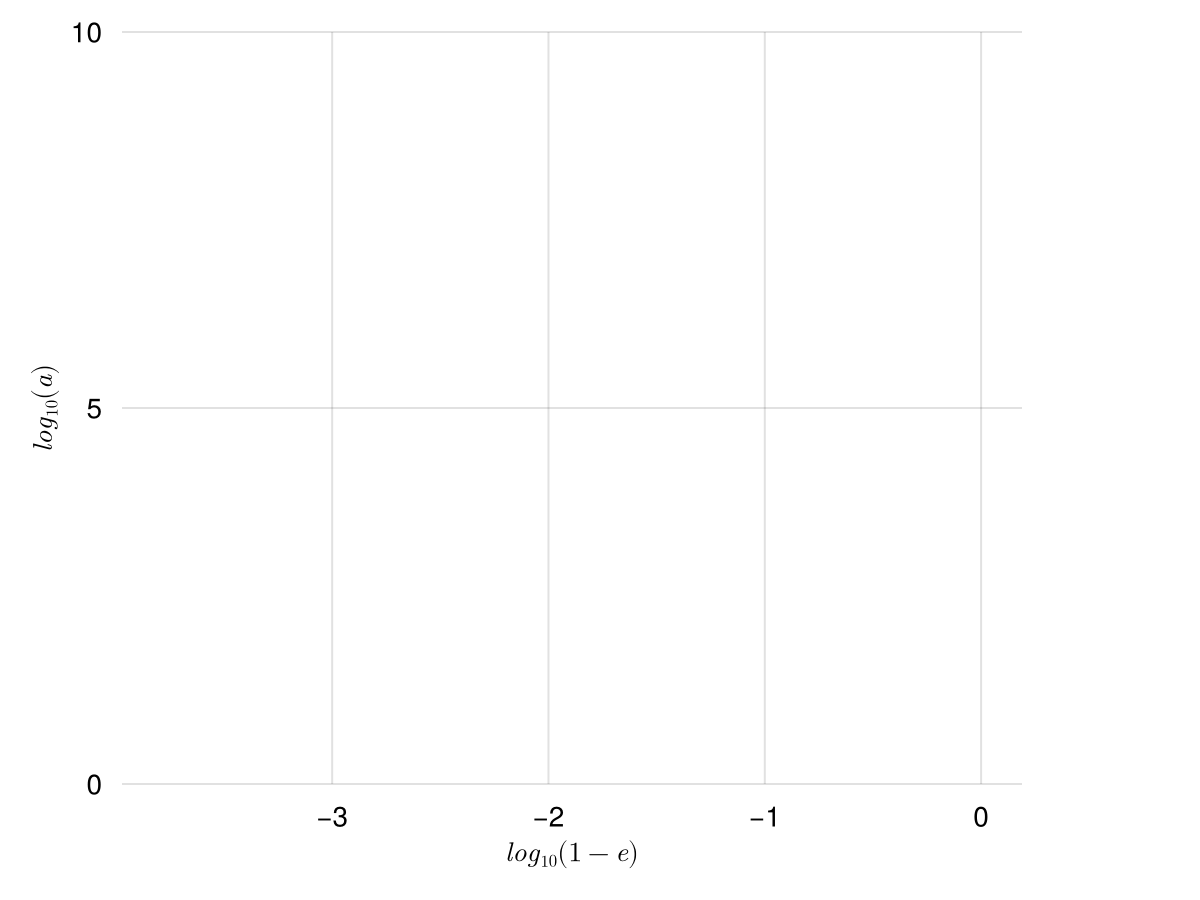

CairoMakie.Screen{IMAGE}


In [80]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel=L"log_{10}(1-e)", ylabel=L"log_{10}(a)")
scatter!(ax, log10.(-df_02.e_cap.+1), log10.(df_02.a_cap), color = df_02.beta_0, colormap = :viridis, colorrange = (1, 15),  markersize = 5)
Colorbar(fig[1, 2], sc, label = L"\Beta")
display(fig)

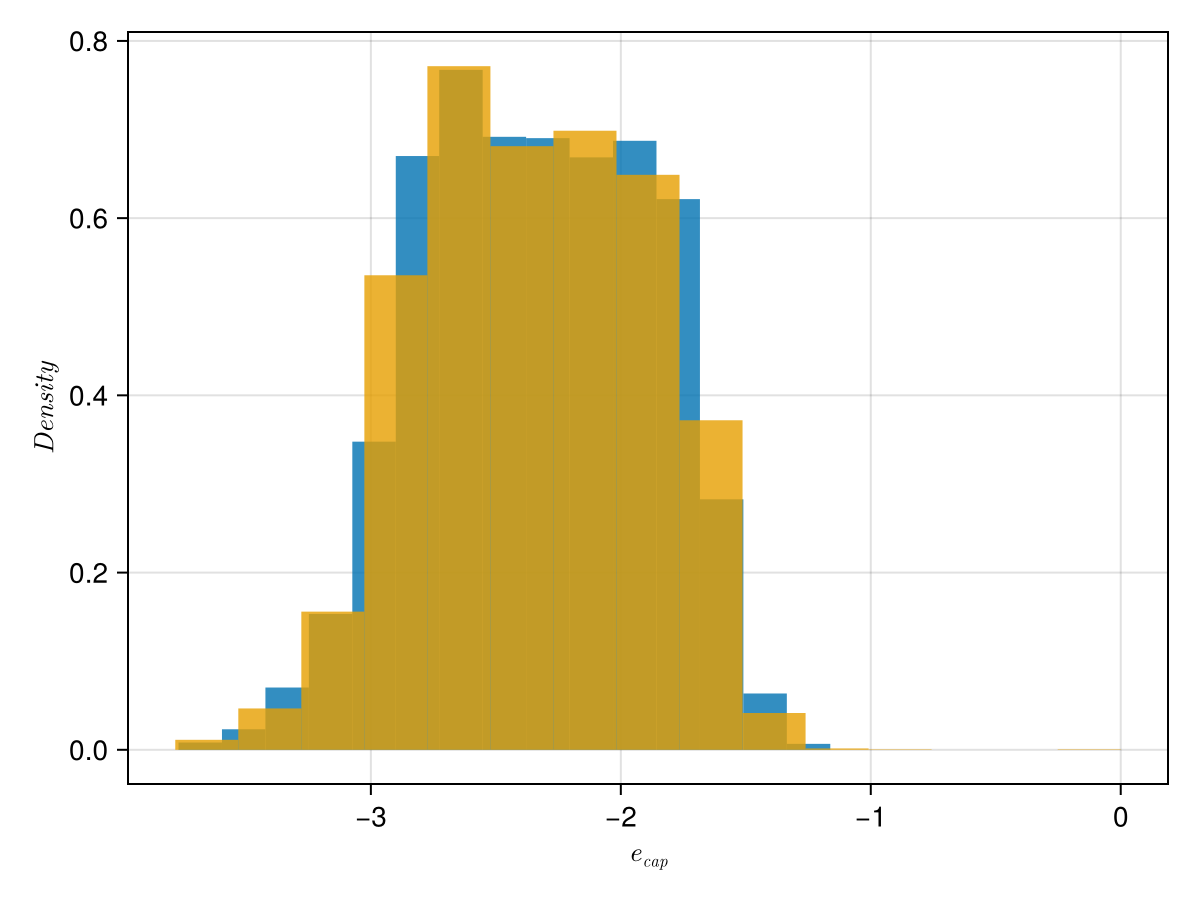

CairoMakie.Screen{IMAGE}


In [135]:
# check statistic stuff

using Plots

x1=df_2.a_cap
y1=-df_2.e_cap.+1
x2=df_02.a_cap
y2=-df_02.e_cap.+1
E0=hcat(x1,y1)
E1=hcat(x2,y2)

kdex1=kde(x1)
kdey1=kde(y1)
kdex2=kde(x2)
kdey2=kde(y2)
kde1=kde(E0)
kde2=kde(E1)

fig = Figure()
ax = Axis(fig[1, 1], xlabel=L"e_{cap}", ylabel=L"Density")
hist!(ax, log10.(y1), normalization=:pdf)
hist!(ax, log10.(y2), normalization=:pdf)
display(fig)

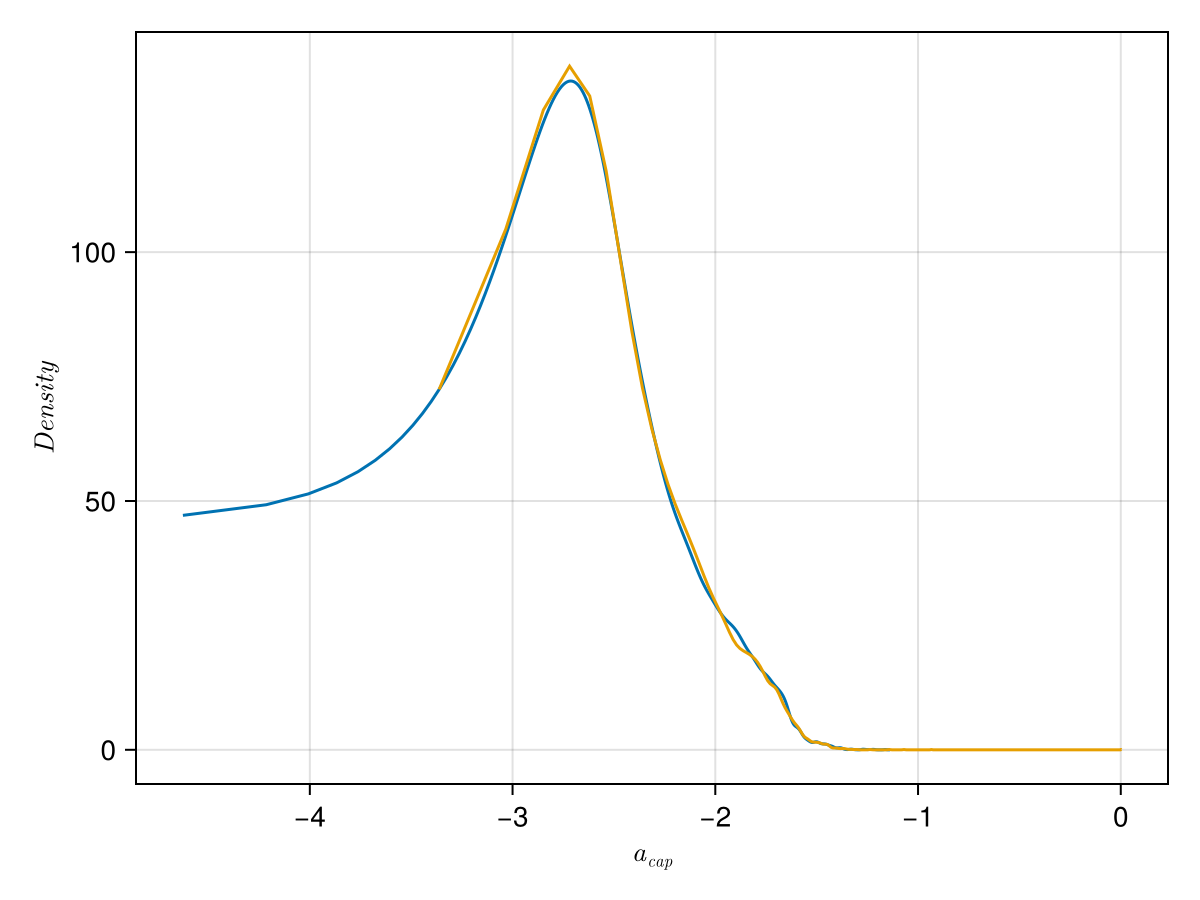

CairoMakie.Screen{IMAGE}


In [128]:
fig = Figure()
ax = Axis(fig[1, 1], xlabel=L"a_{cap}", ylabel=L"Density")
lines!(ax, log10.(kdey1.x[kdey1.x .> 0]), kdey1.density[kdey1.x .> 0])
lines!(ax, log10.(kdey2.x[kdey2.x .> 0]), kdey2.density[kdey2.x .> 0])
display(fig)

In [88]:
xgrid = range(minimum([minimum(x1), minimum(x2)]), stop=maximum([maximum(x1), maximum(x2)]), length=100)
ygrid = range(minimum([minimum(y1), minimum(y2)]), stop=maximum([maximum(y1), maximum(y2)]), length=100)
z1 = [pdf(kde1, xi, yi) for yi in ygrid, xi in xgrid] 
z2 = [pdf(kde2, xi, yi) for yi in ygrid, xi in xgrid];


100×100 Matrix{Float64}:
   0.472009     214.362       …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
   4.88903     6070.42           0.0  0.0  0.0  0.0  0.0  0.0  0.0
  36.6858      4728.4            0.0  0.0  0.0  0.0  0.0  0.0  0.0
  59.76        2560.44           0.0  0.0  0.0  0.0  0.0  0.0  0.0
  18.9381       382.437          0.0  0.0  0.0  0.0  0.0  0.0  0.0
  12.0313        -0.546531    …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
   4.37086       -0.104997       0.0  0.0  0.0  0.0  0.0  0.0  0.0
  37.3882         0.223594       0.0  0.0  0.0  0.0  0.0  0.0  0.0
   9.82523        0.103695       0.0  0.0  0.0  0.0  0.0  0.0  0.0
   1.73045        0.00218171     0.0  0.0  0.0  0.0  0.0  0.0  0.0
  -0.0551388      0.0269415   …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
   2.70537        0.0474494      0.0  0.0  0.0  0.0  0.0  0.0  0.0
   6.42453        0.0181524      0.0  0.0  0.0  0.0  0.0  0.0  0.0
   ⋮                          ⋱            ⋮                   
   7.00788e-6     2.43107e-5     0.0  0.

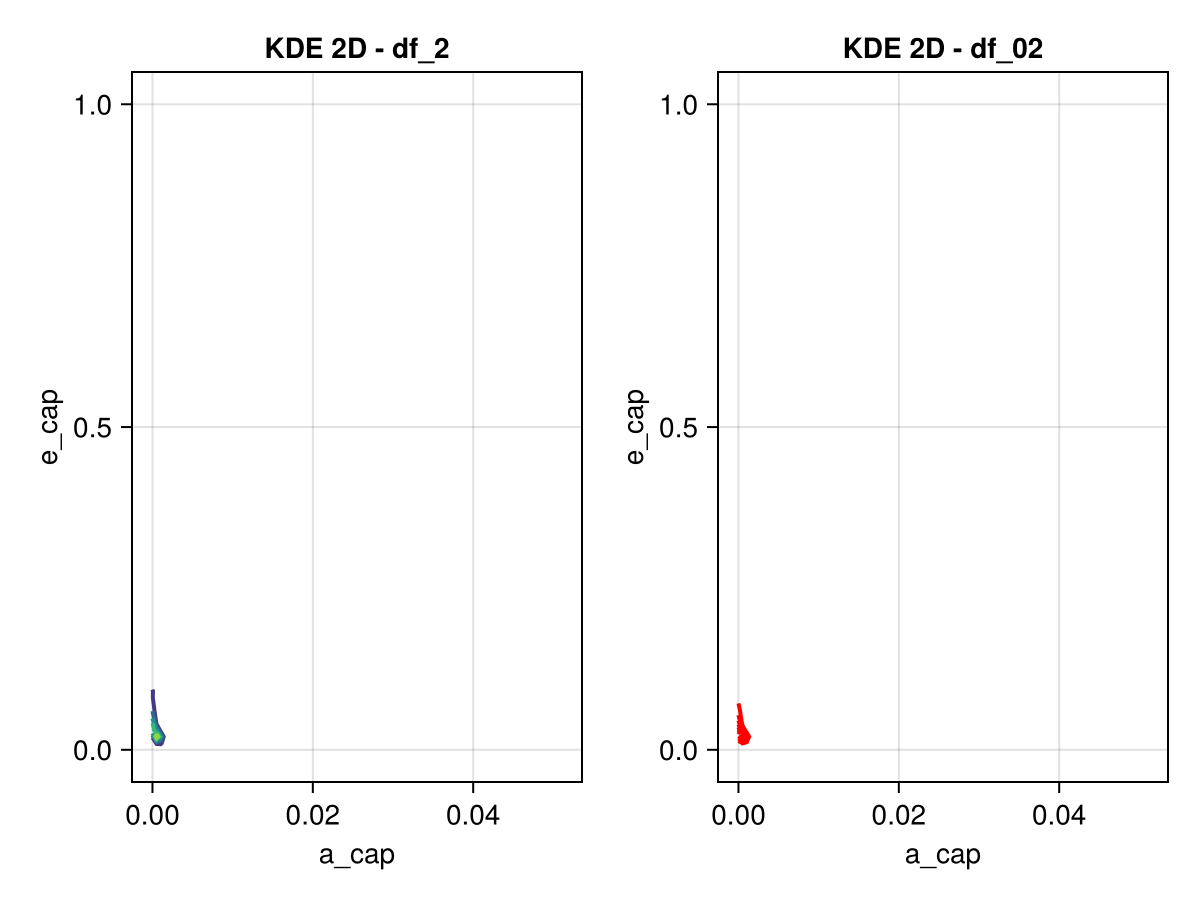

CairoMakie.Screen{IMAGE}


In [89]:
fig = Figure()

ax1 = Axis(fig[1, 1], title = "KDE 2D - df_2", xlabel = "a_cap", ylabel = "e_cap")
CairoMakie.contour!(ax1, xgrid, ygrid, z1; linewidth = 2)

ax2 = Axis(fig[1, 2], title = "KDE 2D - df_02", xlabel = "a_cap", ylabel = "e_cap")
CairoMakie.contour!(ax2, xgrid, ygrid, z2; linewidth = 2, color = :red)

display(fig)